<a href="https://colab.research.google.com/github/anweshkumarsv/MedImpute-X/blob/main/Copy_of_major_project_MedImputeX_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1

In [ ]:
# Cell 1 — install & imports
!pip install --quiet --upgrade pandas_gbq google-cloud-bigquery torch torchvision torchaudio matplotlib seaborn scikit-learn tqdm

import os, math, time, random
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# BigQuery
from google.colab import auth
auth.authenticate_user()
from pandas_gbq import read_gbq
PROJECT_ID = "medimpute-x"   # your project
TABLE = "medimpute-x.mimic_subset.hourly_features_final"

# REPRODUCIBILITY


SEED = 42

import os
import random
import numpy as np
import torch

# Python / NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch CPU/GPU
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Extra reproducibility
os.environ["PYTHONHASHSEED"] = str(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("SEED:", SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1

In [ ]:
# Cell 2 — schema / feature lists
NUMERIC_FEATURES = [
    "hr","rr","spo2","temp","sbp","dbp","map",
    "creatinine","lactate","glucose","sodium","potassium","wbc"
]
MASK_FEATURES = [f + "_mask" for f in NUMERIC_FEATURES]
META_FEATURES = ["subject_id","stay_id","hour","anchor_age","gender","hospital_expire_flag"]

MAX_HOURS_PER_STAY = 48   # change per dataset characteristics
print("Numeric features:", NUMERIC_FEATURES)
print("Mask features:", MASK_FEATURES)


Numeric features: ['hr', 'rr', 'spo2', 'temp', 'sbp', 'dbp', 'map', 'creatinine', 'lactate', 'glucose', 'sodium', 'potassium', 'wbc']
Mask features: ['hr_mask', 'rr_mask', 'spo2_mask', 'temp_mask', 'sbp_mask', 'dbp_mask', 'map_mask', 'creatinine_mask', 'lactate_mask', 'glucose_mask', 'sodium_mask', 'potassium_mask', 'wbc_mask']


In [ ]:
# Cell 3 — helper functions to fetch data in stay_id batches to avoid OOM
from math import ceil

def get_unique_stay_ids(limit=None):
    q = f"SELECT DISTINCT stay_id FROM `{TABLE}`"
    if limit is not None:
        q += f" LIMIT {limit}"
    df_ids = read_gbq(q, project_id=PROJECT_ID)
    return df_ids['stay_id'].tolist()

def fetch_stays_batch(stay_ids):
    # fetch rows for this list of stays
    ids_str = ",".join(map(str, stay_ids))
    q = f"""
    SELECT subject_id, stay_id, hour, {', '.join(NUMERIC_FEATURES)}, {', '.join(MASK_FEATURES)},
           anchor_age, gender, hospital_expire_flag
    FROM `{TABLE}`
    WHERE stay_id IN ({ids_str})
    """
    return read_gbq(q, project_id=PROJECT_ID)

# Example: inspect how many unique stays are available (first small call)
print("Fetching up to 200 stay ids (quick check)...")
small_ids = get_unique_stay_ids(limit=200)
print("Found sample of stay_ids:", len(small_ids))


Fetching up to 200 stay ids (quick check)...
Downloading: 100%|██████████|
Found sample of stay_ids: 200


In [ ]:
# Cell 4 — load stays in batches to reach a target number of stays while keeping memory safe
TARGET_STAYS = 2000   # increase if memory allows; start low to test
BATCH_SIZE_STAYS = 200

all_stay_ids = get_unique_stay_ids()   # WARNING: if huge, you can pass limit arg instead
print("Total available stays (discrete):", len(all_stay_ids))

# Choose a random sample of stay ids (to ensure distributed sample)
rng = np.random.default_rng(SEED)

selected_ids = rng.choice(
    all_stay_ids,
    size=min(TARGET_STAYS, len(all_stay_ids)),
    replace=False
).tolist()
print(f"Selected {len(selected_ids)} stay ids for ingestion.")

# Fetch in chunks
chunks = [selected_ids[i:i+BATCH_SIZE_STAYS] for i in range(0, len(selected_ids), BATCH_SIZE_STAYS)]
dfs = []
for i,chunk in enumerate(chunks):
    print(f"Fetching chunk {i+1}/{len(chunks)} with {len(chunk)} stays ...")
    df_chunk = fetch_stays_batch(chunk)
    dfs.append(df_chunk)
    # optional small sleep to avoid quota bursts
    time.sleep(1.0)

df = pd.concat(dfs, ignore_index=True)
print("Fetched rows:", df.shape[0])
display(df.head())


Downloading: 100%|██████████|
Total available stays (discrete): 65354
Selected 2000 stay ids for ingestion.
Fetching chunk 1/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 2/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 3/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 4/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 5/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 6/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 7/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 8/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 9/10 with 200 stays ...
Downloading: 100%|██████████|
Fetching chunk 10/10 with 200 stays ...
Downloading: 100%|██████████|
Fetched rows: 164881


,subject_id,stay_id,hour,hr,rr,spo2,temp,sbp,dbp,map,...,map_mask,creatinine_mask,lactate_mask,glucose_mask,sodium_mask,potassium_mask,wbc_mask,anchor_age,gender,hospital_expire_flag
0,12515895,30996393,2141-11-24 15:00:00,101.0,18.0,NaN,NaN,116.0,70.0,NaN,...,0,0,0,0,0,0,0,56,M,0
1,12515895,30996393,2141-11-24 16:00:00,89.0,17.0,NaN,NaN,124.0,59.0,NaN,...,0,0,0,0,0,0,0,56,M,0
2,12515895,30996393,2141-11-24 12:00:00,110.0,18.0,NaN,98.8,136.0,78.0,NaN,...,0,0,0,0,0,0,0,56,M,0
3,12515895,30996393,2141-11-24 14:00:00,109.0,17.0,NaN,NaN,142.0,78.0,NaN,...,0,0,0,0,0,0,0,56,M,0
4,13526596,38840683,2156-04-06 06:00:00,56.0,18.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,68,F,0


In [ ]:
# Cell 5 — cleaning & ensure masks presence
for f in NUMERIC_FEATURES:
    df[f] = pd.to_numeric(df[f], errors='coerce')

# If mask columns missing, create them from NaNs
for f in NUMERIC_FEATURES:
    m = f + "_mask"
    if m not in df.columns:
        df[m] = (~df[f].isna()).astype(int)
    else:
        df[m] = pd.to_numeric(df[m], errors='coerce').fillna(0).astype(int)

# Sort and preview
df = df.sort_values(['stay_id','hour'])
print("After cleaning, rows:", df.shape[0])
display(df[[ 'stay_id','hour'] + NUMERIC_FEATURES + MASK_FEATURES].head(10))


After cleaning, rows: 164881


,stay_id,hour,hr,rr,spo2,temp,sbp,dbp,map,creatinine,...,temp_mask,sbp_mask,dbp_mask,map_mask,creatinine_mask,lactate_mask,glucose_mask,sodium_mask,potassium_mask,wbc_mask
81330,30004242,2180-11-19 01:00:00,59.0,21.0,NaN,98.1,107.0,90.0,NaN,NaN,...,1,1,1,0,0,0,0,0,0,0
81430,30004242,2180-11-19 02:00:00,60.0,19.0,NaN,NaN,92.0,74.0,NaN,NaN,...,0,1,1,0,0,0,0,0,0,0
81332,30004242,2180-11-19 03:00:00,46.0,16.0,NaN,NaN,120.0,34.0,NaN,NaN,...,0,1,1,0,0,0,0,0,0,0
81365,30004242,2180-11-19 04:00:00,46.0,18.0,NaN,NaN,NaN,NaN,NaN,0.5,...,0,0,0,0,1,0,1,1,1,0
81363,30004242,2180-11-19 05:00:00,48.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
81400,30004242,2180-11-19 06:00:00,46.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
81390,30004242,2180-11-19 07:00:00,49.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
81337,30004242,2180-11-19 08:00:00,50.0,19.0,NaN,98.7,NaN,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,0
81341,30004242,2180-11-19 09:00:00,47.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
81338,30004242,2180-11-19 10:00:00,41.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Cell 6 — build sequences of shape (n_stays, T, D) and masks (n_stays, T, D)
T = MAX_HOURS_PER_STAY
D = len(NUMERIC_FEATURES)

def build_sequences(df, max_len=T):
    stays = []
    for stay_id, g in df.groupby('stay_id'):
        g = g.sort_values('hour')
        vals = g[NUMERIC_FEATURES].values.astype(float)
        masks = g[MASK_FEATURES].values.astype(float)
        # pad or truncate
        if vals.shape[0] >= max_len:
            vals = vals[:max_len]
            masks = masks[:max_len]
        else:
            pad_len = max_len - vals.shape[0]
            vals = np.vstack([vals, np.full((pad_len, D), np.nan)])
            masks = np.vstack([masks, np.zeros((pad_len, D))])
        stays.append({'stay_id': stay_id, 'values': vals, 'masks': masks})
    return stays

stays = build_sequences(df, max_len=T)
print("Prepared sequences for stays:", len(stays))
# quick sanity checks
print("Example stay has shape:", stays[0]['values'].shape, stays[0]['masks'].shape)


Prepared sequences for stays: 2000
Example stay has shape: (48, 13) (48, 13)


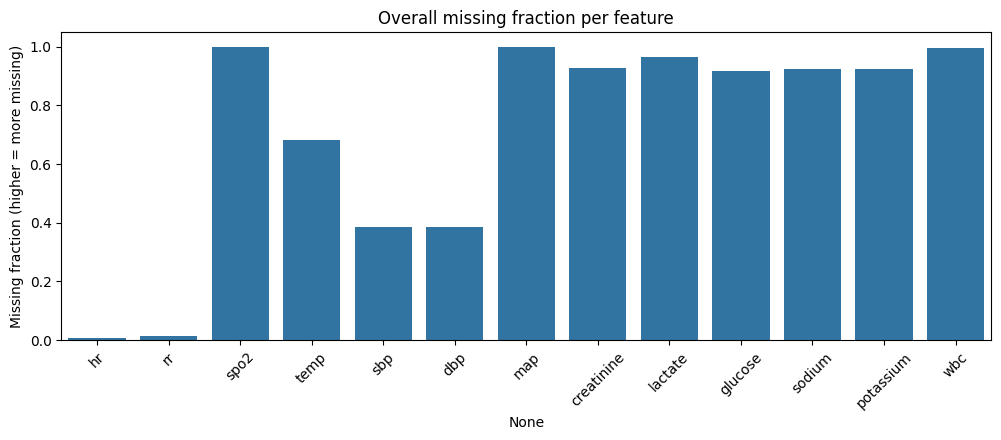

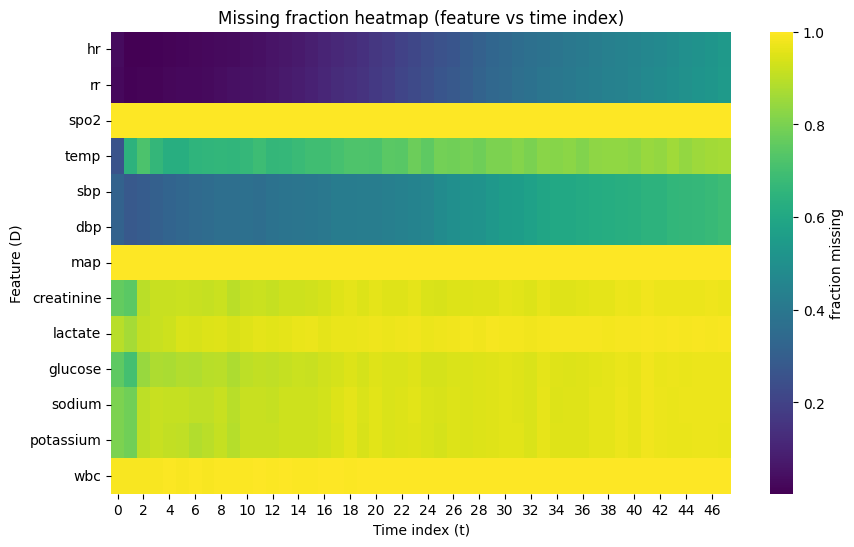

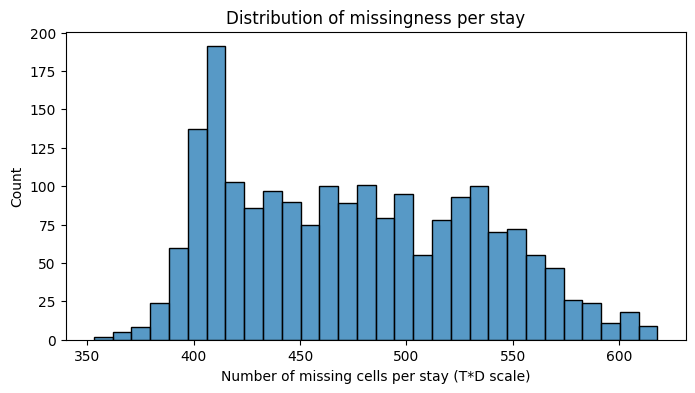

In [ ]:
# Cell 7 — exploratory visualizations (multiple)
# 1) overall missing fraction per feature (bar)
full_df = df.copy()
miss_frac = full_df[NUMERIC_FEATURES].isna().mean()
plt.figure(figsize=(12,4))
sns.barplot(x=miss_frac.index, y=miss_frac.values)
plt.title("Overall missing fraction per feature")
plt.ylabel("Missing fraction (higher = more missing)")
plt.xticks(rotation=45)
plt.show()

# 2) Missingness heatmap across time (aggregate across stays) — fraction missing at each hour index (0..T-1)
# Build matrix T x D where value = fraction missing at that time-position across stays
missing_matrix = np.zeros((T,D))
counts_matrix = np.zeros((T,D))
for s in stays:
    masks = s['masks']  # T x D
    for t in range(T):
        missing_matrix[t] += (1 - masks[t])   # missing indicator
        counts_matrix[t] += 1
missing_frac_by_time = missing_matrix / np.maximum(counts_matrix,1)

plt.figure(figsize=(10,6))
sns.heatmap(missing_frac_by_time.T, cmap="viridis", cbar_kws={'label':'fraction missing'})
plt.xlabel("Time index (t)")
plt.ylabel("Feature (D)")
plt.yticks(np.arange(D)+0.5, NUMERIC_FEATURES, rotation=0)
plt.title("Missing fraction heatmap (feature vs time index)")
plt.show()

# 3) Per-stay missingness distribution histogram (how many missing cells per stay)
missing_counts = [int(np.sum(s['masks']==0)) for s in stays]
plt.figure(figsize=(8,4))
sns.histplot(missing_counts, bins=30, kde=False)
plt.xlabel("Number of missing cells per stay (T*D scale)")
plt.title("Distribution of missingness per stay")
plt.show()


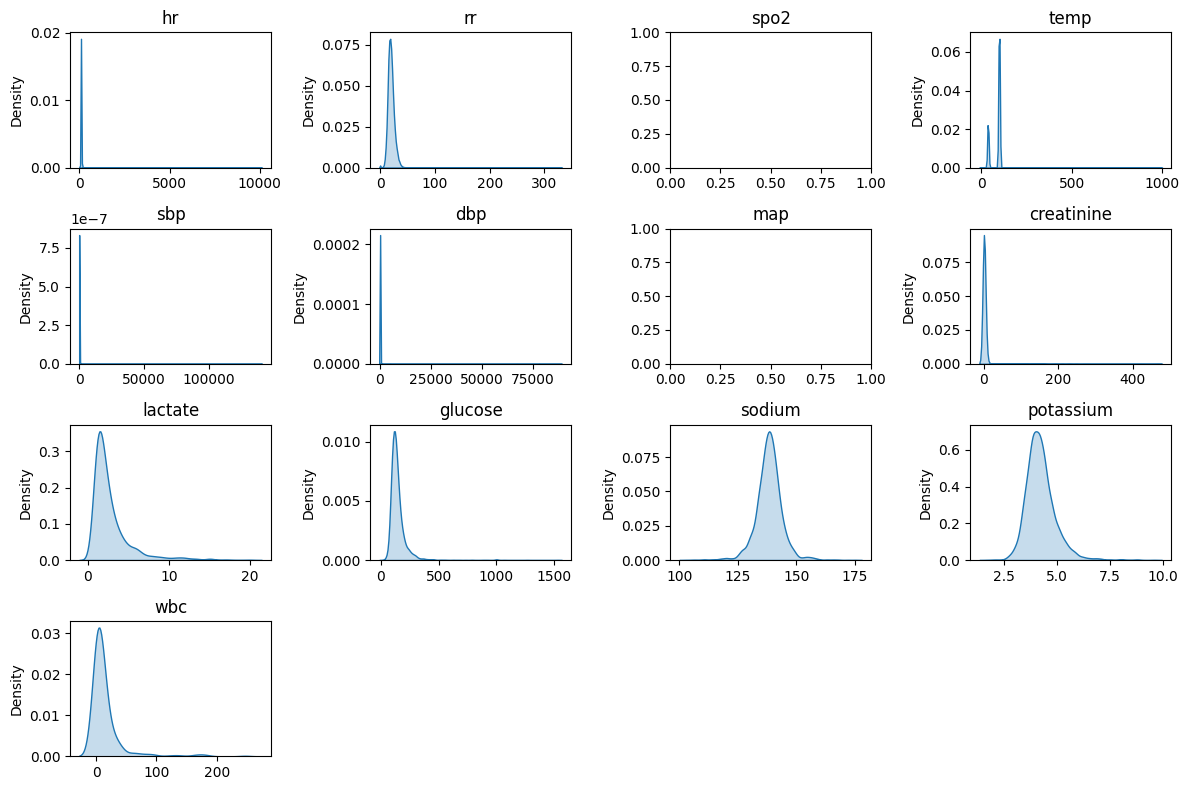

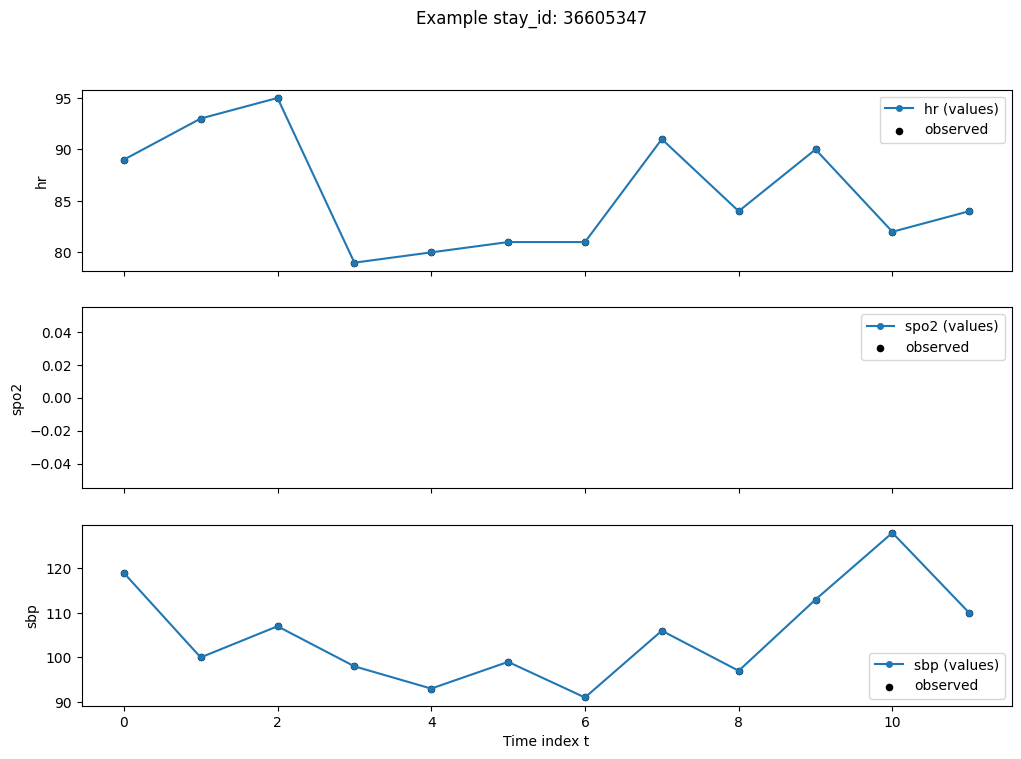

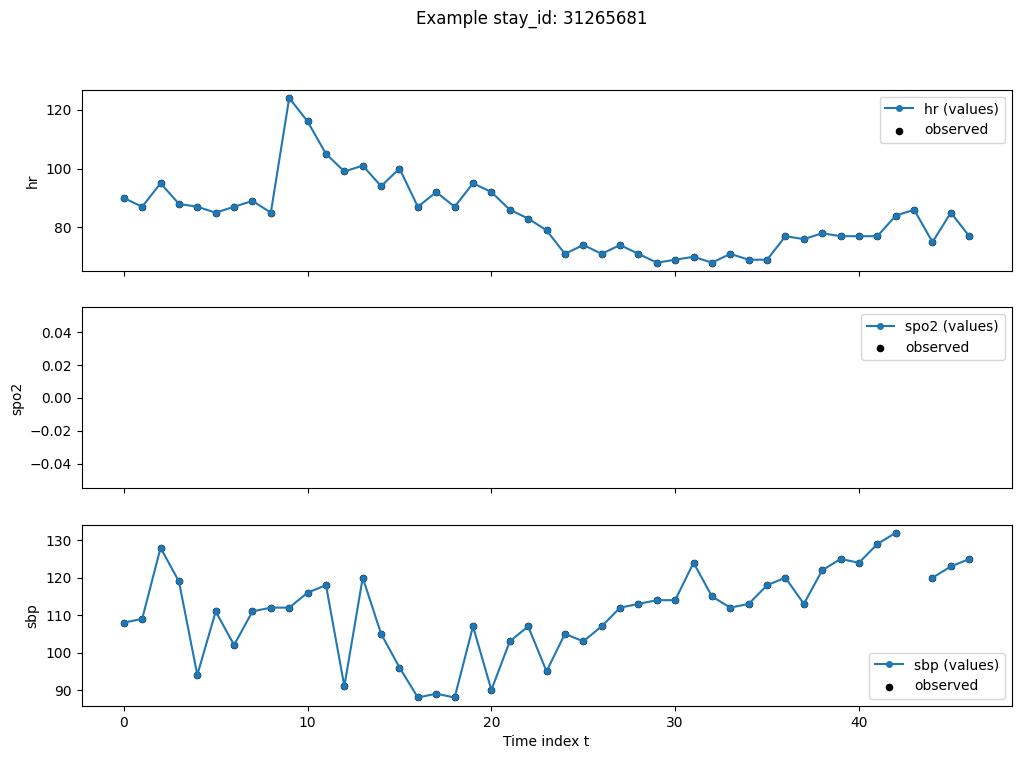

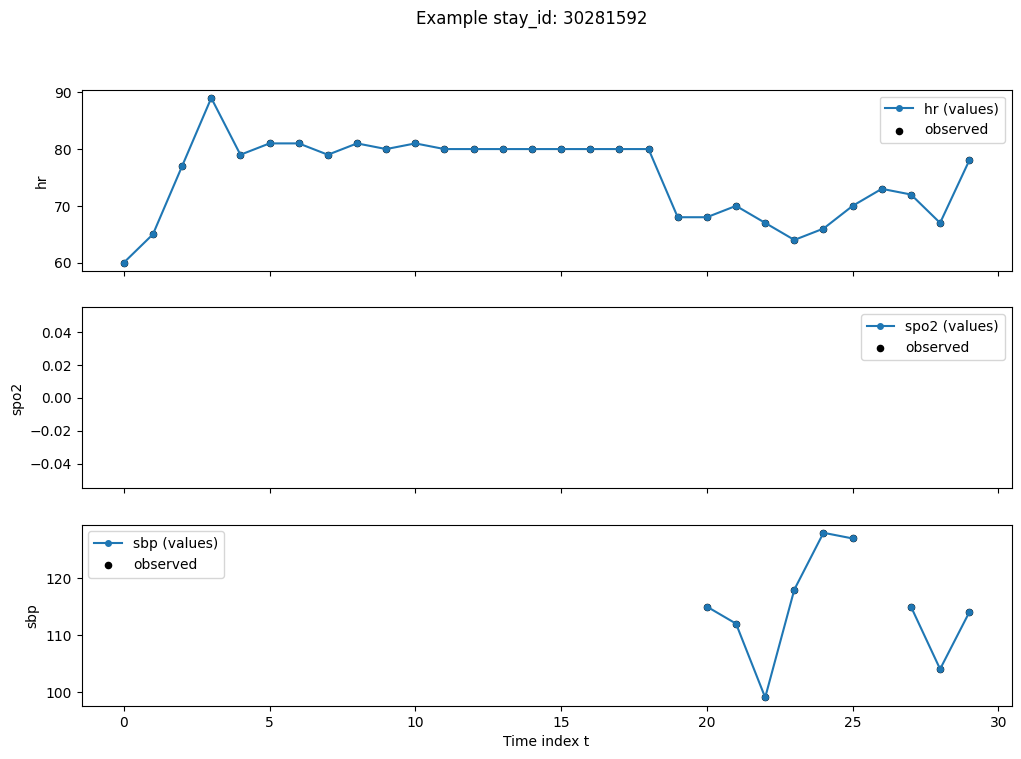

In [ ]:
# Cell 8 — distributions and time-series examples
# Gather observed values per feature
obs_vals = {f: [] for f in NUMERIC_FEATURES}
for s in stays:
    vals = s['values']
    masks = s['masks']
    for i,f in enumerate(NUMERIC_FEATURES):
        obs = vals[:,i][masks[:,i]==1]
        if len(obs)>0:
            obs_vals[f].extend(obs.tolist())

# Plot KDE for each feature (observed)
plt.figure(figsize=(12,8))
for i,f in enumerate(NUMERIC_FEATURES):
    plt.subplot(4,4,i+1)
    if len(obs_vals[f])>0:
        sns.kdeplot(obs_vals[f], fill=True)
    plt.title(f)
plt.tight_layout()
plt.show()

# Example time-series: pick 3 random stays and plot few features with missing indicated
sample_stays = random.sample(stays, min(3, len(stays)))
for idx, s in enumerate(sample_stays):
    vals = s['values']
    masks = s['masks']
    t = np.arange(T)
    # plot 3 important vitals in same figure: hr, spo2, sbp (if available)
    fig, axes = plt.subplots(3,1, figsize=(12,8), sharex=True)
    sel_features = ['hr','spo2','sbp']
    for ax_i, feat in enumerate(sel_features):
        i = NUMERIC_FEATURES.index(feat)
        ax = axes[ax_i]
        ax.plot(t, vals[:,i], label=f"{feat} (values)", marker='o', markersize=4)
        # highlight observed points
        observed_idx = masks[:,i]==1
        ax.scatter(t[observed_idx], vals[observed_idx,i], color='black', s=20, label='observed')
        ax.set_ylabel(feat)
        ax.legend()
    plt.suptitle(f"Example stay_id: {s['stay_id']}")
    plt.xlabel("Time index t")
    plt.show()


**N-Series**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------
# N1 — Train/Val/Test Split (by stay_id) + Fit Scaler
# ----------------------------------------------------

all_stay_ids = df['stay_id'].unique()

train_ids, test_ids = train_test_split(all_stay_ids, test_size=0.2, random_state=42)
train_ids, val_ids  = train_test_split(train_ids, test_size=0.125, random_state=42)

df_train = df[df['stay_id'].isin(train_ids)].copy()
df_val   = df[df['stay_id'].isin(val_ids)].copy()
df_test  = df[df['stay_id'].isin(test_ids)].copy()

print("Stays -> Train:", len(train_ids), " Val:", len(val_ids), " Test:", len(test_ids))

# Fit scaler ONLY on training numeric features to avoid leakage
scaler = StandardScaler()
scaler.fit(df_train[NUMERIC_FEATURES])

# Apply scaling to each split
df_train_scaled = df_train.copy()
df_val_scaled   = df_val.copy()
df_test_scaled  = df_test.copy()

df_train_scaled[NUMERIC_FEATURES] = scaler.transform(df_train[NUMERIC_FEATURES])
df_val_scaled[NUMERIC_FEATURES]   = scaler.transform(df_val[NUMERIC_FEATURES])
df_test_scaled[NUMERIC_FEATURES]  = scaler.transform(df_test[NUMERIC_FEATURES])

# Combine scaled dataset back (preserving time order)
df_scaled = pd.concat([df_train_scaled, df_val_scaled, df_test_scaled]).sort_values(["stay_id","hour"])

print("✅ Scaling complete. Example scaled rows:")
display(df_scaled.head())

Stays -> Train: 1400  Val: 200  Test: 400
✅ Scaling complete. Example scaled rows:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


,subject_id,stay_id,hour,hr,rr,spo2,temp,sbp,dbp,map,...,map_mask,creatinine_mask,lactate_mask,glucose_mask,sodium_mask,potassium_mask,wbc_mask,anchor_age,gender,hospital_expire_flag
81330,17220323,30004242,2180-11-19 01:00:00,-0.022679,0.057308,NaN,0.500871,-0.029405,0.039575,NaN,...,0,0,0,0,0,0,0,75,F,0
81430,17220323,30004242,2180-11-19 02:00:00,-0.021944,-0.131889,NaN,NaN,-0.057537,0.008599,NaN,...,0,0,0,0,0,0,0,75,F,0
81332,17220323,30004242,2180-11-19 03:00:00,-0.032233,-0.415686,NaN,NaN,-0.005024,-0.068841,NaN,...,0,0,0,0,0,0,0,75,F,0
81365,17220323,30004242,2180-11-19 04:00:00,-0.032233,-0.226488,NaN,NaN,NaN,NaN,NaN,...,0,1,0,1,1,1,0,75,F,0
81363,17220323,30004242,2180-11-19 05:00:00,-0.030763,-0.321087,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,75,F,0


In [ ]:
# ----------------------------------------------------
# N2 — Build sequences from df_scaled (NOT df)
# ----------------------------------------------------

# Use the SAME build_sequences function as before
stays = build_sequences(df_scaled, max_len=T)
print("Sequences built from scaled data:", len(stays))

Sequences built from scaled data: 2000


In [ ]:
# ----------------------------------------------------
# N3 — Save feature means/std for inverse scaling later
# ----------------------------------------------------

feature_means = scaler.mean_
feature_stds  = scaler.scale_

print("Saved means:", feature_means)
print("Saved stds :", feature_stds)

Saved means: [ 89.8570254   20.39419464          nan  85.09467109 122.67884618
  69.55825042          nan   4.06906587   2.46563728 144.98137101
 138.98532423   4.15221105  18.1690367 ]
Saved stds : [1.36061195e+03 1.05709580e+01            nan 2.59654388e+01
 5.33205808e+02 5.16528906e+02            nan 1.84341756e+01
 2.39597591e+00 6.83164618e+01 6.09198644e+00 6.44317664e-01
 4.95695881e+01]


In [ ]:
# ----------------------------------------------------
# N4 — Artificial masking remains unchanged (no edits)
# ----------------------------------------------------
print("N4: Artificial masking OK — no changes needed.")

N4: Artificial masking OK — no changes needed.


In [ ]:
# ----------------------------------------------------
# N5 — Unscaled evaluation helpers for RMSE/MAE
# ----------------------------------------------------

def unscale(pred_tensor):
    """Convert normalized model predictions back to original scale."""
    pred = pred_tensor.cpu().numpy()
    return pred * feature_stds + feature_means

def unscale_np(arr):
    """Convert normalized numpy GT array back to original scale."""
    return arr * feature_stds + feature_means

def evaluate_model_unscaled(model, loader, hide_fraction=0.12):
    """Evaluate ANY model (BRITS, SAITS, GAN, Fusion) in REAL units."""
    model.eval()
    pred_vals = []
    gt_vals   = []

    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(DEVICE)     # normalized input
            m = batch['m'].to(DEVICE)

            # Artificially hide some observed entries
            x_art, m_art, hidden = apply_mask(x, m, mode="block")

            pred, *_ = model(x_art, m_art)   # model output (normalized)

            # Convert predictions + GT back to real scale
            pred_real = unscale(pred)
            gt_real   = unscale_np(x.cpu().numpy())

            # Collect evaluation data
            for ((b, t, d), gt_scaled) in hidden:
                pred_vals.append(pred_real[b, t, d])
                gt_vals.append(gt_real[b, t, d])

    # Compute final metrics
    rmse = np.sqrt(mean_squared_error(gt_vals, pred_vals))
    mae  = mean_absolute_error(gt_vals, pred_vals)

    return rmse, mae, len(gt_vals)

print("✅ Normalization Steps N1–N5 completed successfully!")

✅ Normalization Steps N1–N5 completed successfully!


In [ ]:
# =============================================
# PART 1 — CELL 9
# Build X, M, and DataLoaders from NORMALIZED stays
# =============================================

from torch.utils.data import Dataset, DataLoader   # <-- MISSING IMPORT FIXED HERE

print("🔧 Building normalized arrays and DataLoaders...")

# stays were already rebuilt from df_scaled in N2
n = len(stays)

# Build normalized X and mask M
X = np.stack([np.nan_to_num(s['values'], nan=0.0) for s in stays])   # normalized values
M = np.stack([s['masks'] for s in stays])                           # masks stay the same

# stay_id list (optional for analysis)
stay_ids = [s['stay_id'] for s in stays]

# new train/val/test split (based on NORMALIZED stays)
train_idx, test_idx = train_test_split(np.arange(n), test_size=0.2, random_state=SEED)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.125, random_state=SEED)

print("train/val/test sizes:", len(train_idx), len(val_idx), len(test_idx))

# dataset class supporting normalized X, M
class TimeSeriesDataset(Dataset):
    def __init__(self, X, M, idxs):
        self.X = torch.tensor(X[idxs], dtype=torch.float32)
        self.M = torch.tensor(M[idxs], dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return {
            'x': self.X[i],   # normalized input
            'm': self.M[i]
        }

BATCH_SIZE = 32
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    TimeSeriesDataset(X, M, train_idx),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g
)

val_loader = DataLoader(
    TimeSeriesDataset(X, M, val_idx),
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=g
)

test_loader = DataLoader(
    TimeSeriesDataset(X, M, test_idx),
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=g
)

print("✅ Normalized DataLoaders ready (train/val/test).")


🔧 Building normalized arrays and DataLoaders...
train/val/test sizes: 1400 200 400
✅ Normalized DataLoaders ready (train/val/test).


Part 2

In [ ]:
# Part2 — Cell A (UPDATED)
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm

# ----------------------------------------
# Correct per-feature delta computation
# ----------------------------------------
def compute_delta_matrix(m):
    """
    Computes per-feature delta values (time since last observation).
    m: (B, T, D)
    Returns: delta (B, T, D)
    """
    B, T, D = m.shape
    delta = torch.zeros(B, T, D, device=m.device)
    delta[:, 0, :] = 1.0

    for t in range(1, T):
        observed = m[:, t, :]
        delta[:, t, :] = observed * 1.0 + (1 - observed) * (delta[:, t - 1, :] + 1.0)
    return delta


# ----------------------------------------
# Stable artificial mask with RNG
# ----------------------------------------
def create_artificial_mask_batch(x, m, hide_fraction=0.12, seed=42):
    """
    Stable artificial masking for evaluation & consistency loss.
    """
    rng = np.random.default_rng(seed)
    x_np = x.cpu().numpy()
    m_np = m.cpu().numpy()

    x_c = x_np.copy()
    m_c = m_np.copy()
    hidden = []

    obs_positions = np.argwhere(m_c == 1)
    n_hide = int(len(obs_positions) * hide_fraction)

    if n_hide == 0:
        return torch.tensor(x_c).to(x.device), torch.tensor(m_c).to(m.device), hidden

    chosen = rng.choice(len(obs_positions), size=n_hide, replace=False)

    for idx in chosen:
        b, t, d = obs_positions[idx]
        hidden.append(((b, t, d), x_c[b, t, d]))
        x_c[b, t, d] = 0.0
        m_c[b, t, d] = 0.0

    return (
        torch.tensor(x_c, dtype=torch.float32).to(x.device),
        torch.tensor(m_c, dtype=torch.float32).to(m.device),
        hidden,
    )


In [ ]:
# ==========================================================
# ADDITIONAL MISSINGNESS PATTERNS (DO NOT MODIFY ABOVE CODE)
# ==========================================================

def subsequence_mask(x, m, seed=42):
    rng = np.random.default_rng(seed)
    x_c = x.cpu().numpy().copy()
    m_c = m.cpu().numpy().copy()
    B, T, D = x_c.shape
    hidden = []

    for b in range(B):
        d = rng.integers(0, D)
        length = rng.integers(3, T//3)
        start = rng.integers(0, T - length)
        for t in range(start, start + length):
            if m_c[b, t, d] == 1:
                hidden.append(((b, t, d), x_c[b, t, d]))
                x_c[b, t, d] = 0.0
                m_c[b, t, d] = 0.0

    return torch.tensor(x_c).to(x.device), torch.tensor(m_c).to(m.device), hidden


def block_mask(x, m, seed=42):
    rng = np.random.default_rng(seed)
    x_c = x.cpu().numpy().copy()
    m_c = m.cpu().numpy().copy()
    B, T, D = x_c.shape
    hidden = []

    for b in range(B):
        t0 = rng.integers(0, T//2)
        d0 = rng.integers(0, D//2)
        t_len = rng.integers(3, T//3)
        d_len = rng.integers(1, D//3)

        for t in range(t0, min(T, t0 + t_len)):
            for d in range(d0, min(D, d0 + d_len)):
                if m_c[b, t, d] == 1:
                    hidden.append(((b, t, d), x_c[b, t, d]))
                    x_c[b, t, d] = 0.0
                    m_c[b, t, d] = 0.0

    return torch.tensor(x_c).to(x.device), torch.tensor(m_c).to(m.device), hidden


def apply_mask(x, m, mode="point"):
    if mode == "point":
        return create_artificial_mask_batch(x, m)
    elif mode == "subsequence":
        return subsequence_mask(x, m)
    elif mode == "block":
        return block_mask(x, m)


In [ ]:
# Part2 — Cell B (UPDATED)

class BRITSCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Per-feature → hidden decay projection
        self.decay_linear = nn.Linear(input_dim, hidden_dim)

        self.gru_cell = nn.GRUCell(input_dim, hidden_dim)

    def forward(self, x_t, m_t, delta_t, h_prev):
        # compute gamma = exp(-ReLU(W * delta))
        gamma = torch.exp(-torch.relu(self.decay_linear(delta_t)))  # (B, H)
        h_decay = gamma * h_prev

        # impute missing x_t
        x_hat = m_t * x_t + (1 - m_t) * self.gru_cell.weight_hh.new_zeros(x_t.shape)

        h_new = self.gru_cell(x_hat, h_decay)

        return h_new


class BRITS(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.fcell = BRITSCell(input_dim, hidden_dim)
        self.bcell = BRITSCell(input_dim, hidden_dim)

        self.fc = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, m):
        B, T, D = x.shape
        delta_fwd = compute_delta_matrix(m)
        delta_bwd = torch.flip(delta_fwd, dims=[1])

        # forward pass
        h_f = torch.zeros(B, self.hidden_dim, device=x.device)
        f_list = []
        f_hidden_list = []
        for t in range(T):
            h_f = self.fcell(x[:, t, :], m[:, t, :], delta_fwd[:, t, :], h_f)
            f_hidden_list.append(h_f)
            f_list.append(self.fc(h_f))
        f_pred = torch.stack(f_list, dim=1)

        # backward pass
        h_b = torch.zeros(B, self.hidden_dim, device=x.device)
        b_list = []
        b_hidden_list = []
        for t in reversed(range(T)):
            h_b = self.bcell(x[:, t, :], m[:, t, :], delta_bwd[:, t, :], h_b)
            b_hidden_list.append(h_b)
            b_list.append(self.fc(h_b))
        b_list.reverse()
        b_pred = torch.stack(b_list, dim=1)

        return (f_pred + b_pred) / 2, f_pred, b_pred


In [ ]:
# Part2 - Cell C: BRITS loss definitions
def loss_reconstruction(pred, x, m):
    # pred, x, m: B x T x D
    # compute MSE on observed entries: m == 1
    denom = m.sum()
    if denom == 0:
        return torch.tensor(0.0, device=pred.device)
    loss = ((pred - x)**2 * m).sum() / denom
    return loss

def loss_imputation(pred, x_true, hidden_mask_tensor):
    # Compute loss on hidden artificially masked entries.
    # hidden_mask_tensor: same shape as x, with 1 at hidden positions, 0 elsewhere
    denom = hidden_mask_tensor.sum()
    if denom == 0:
        return torch.tensor(0.0, device=pred.device)
    loss = ((pred - x_true)**2 * hidden_mask_tensor).sum() / denom
    return loss

def loss_consistency(pred_f, pred_b, m_original):
    # pred_f, pred_b: B x T x D forward/back predictions
    # compute MSE between forward and backward predictions on originally missing positions (m_original == 0)
    missing_mask = (1 - m_original)
    denom = missing_mask.sum()
    if denom == 0:
        return torch.tensor(0.0, device=pred_f.device)
    loss = ((pred_f - pred_b)**2 * missing_mask).sum() / denom
    return loss


In [ ]:
# Part2 — Cell D (UPDATED)

def train_brits_full(model, train_loader, val_loader, epochs=40, lr=1e-3,
                     hide_fraction=0.12, alpha_impute=1.0, beta_consis=0.5,
                     device=DEVICE, save_path="brits_best.pth"):

    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)

    train_history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')

    for epoch in range(1, epochs+1):
        model.train()
        train_losses = []

        for batch in train_loader:
            x = batch['x'].to(device)
            m = batch['m'].to(device)

            x_art, m_art, hidden = apply_mask(x, m, mode="block")
            hidden_mask = torch.zeros_like(m, device=device)
            for (btd, _) in hidden:
                b,t,d = btd
                hidden_mask[b,t,d] = 1.0

            pred, pred_f, pred_b = model(x_art, m_art)

            loss_rec = loss_reconstruction(pred, x_art, m_art)
            loss_imp = loss_imputation(pred, x, hidden_mask)
            loss_cons = loss_consistency(pred_f, pred_b, m)

            loss = loss_rec + alpha_impute * loss_imp + beta_consis * loss_cons

            opt.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

            opt.step()
            train_losses.append(loss.item())

        avg_train = np.mean(train_losses)

        # validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                x = batch['x'].to(device)
                m = batch['m'].to(device)
                x_art, m_art, hidden = apply_mask(x, m, mode="block")
                hidden_mask = torch.zeros_like(m, device=device)
                for (btd, _) in hidden:
                    b,t,d = btd
                    hidden_mask[b,t,d] = 1.0

                pred, pred_f, pred_b = model(x_art, m_art)

                loss = (
                    loss_reconstruction(pred, x_art, m_art)
                    + alpha_impute * loss_imputation(pred, x, hidden_mask)
                    + beta_consis * loss_consistency(pred_f, pred_b, m)
                )
                val_losses.append(loss.item())

        avg_val = np.mean(val_losses)
        scheduler.step(avg_val)

        train_history['train_loss'].append(avg_train)
        train_history['val_loss'].append(avg_val)

        print(f"[BRITS] Epoch {epoch}/{epochs}  train={avg_train:.6f}  val={avg_val:.6f}")

        if avg_val < best_val:
            best_val = avg_val
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path))
    return model, train_history


In [ ]:
# Part2 - Cell E: instantiate & run training (adjust epochs as needed)
HIDDEN_DIM = 128
brits_model = BRITS(input_dim=D, hidden_dim=HIDDEN_DIM)

# Training hyperparams — adjust if memory/time constrained
EPOCHS = 30       # increase for production; keep modest for prototype
LR = 1e-3
HIDE_FRAC = 0.12
ALPHA_IMPUTE = 2.0   # weight for imputation loss (paper uses strong imputation loss)
BETA_CONSIS = 0.5    # consistency weight

brits_model, history = train_brits_full(
    brits_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, hide_fraction=HIDE_FRAC,
    alpha_impute=ALPHA_IMPUTE, beta_consis=BETA_CONSIS,
    device=DEVICE, save_path="brits_best.pth"
)


[BRITS] Epoch 1/30  train=1.179036  val=0.276824
[BRITS] Epoch 2/30  train=1.041507  val=0.196087
[BRITS] Epoch 3/30  train=1.122195  val=0.170291
[BRITS] Epoch 4/30  train=0.903268  val=0.151994
[BRITS] Epoch 5/30  train=0.840932  val=0.144958
[BRITS] Epoch 6/30  train=0.972105  val=0.139768
[BRITS] Epoch 7/30  train=0.927646  val=0.137429
[BRITS] Epoch 8/30  train=0.823791  val=0.143003
[BRITS] Epoch 9/30  train=0.927538  val=0.134066
[BRITS] Epoch 10/30  train=0.823211  val=0.130995
[BRITS] Epoch 11/30  train=0.846676  val=0.126545
[BRITS] Epoch 12/30  train=0.919839  val=0.126064
[BRITS] Epoch 13/30  train=0.835734  val=0.124685
[BRITS] Epoch 14/30  train=0.771720  val=0.121828
[BRITS] Epoch 15/30  train=0.853063  val=0.121732
[BRITS] Epoch 16/30  train=0.779067  val=0.122638
[BRITS] Epoch 17/30  train=0.956790  val=0.121847
[BRITS] Epoch 18/30  train=0.729415  val=0.117905
[BRITS] Epoch 19/30  train=0.828089  val=0.116549
[BRITS] Epoch 20/30  train=0.655825  val=0.121602
[BRITS] E

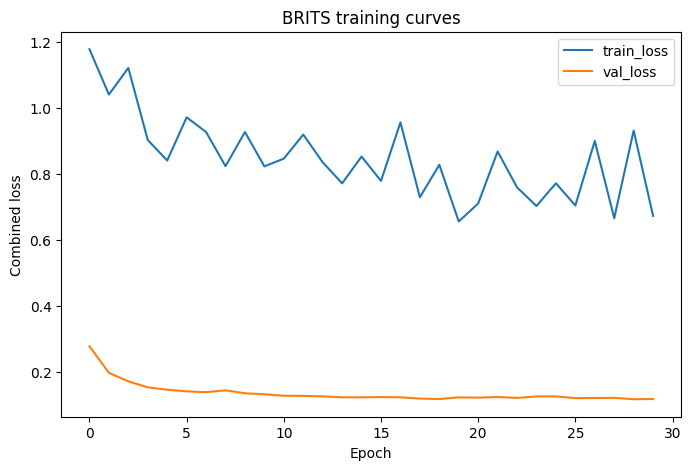

In [ ]:
# Part2 - Cell F: plot training curves
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel("Combined loss")
plt.title("BRITS training curves")
plt.legend()
plt.show()


In [ ]:
# Part2 - Cell G: evaluation with artificial masking on test loader
def impute_batch_brits(model, x, m):
    # x,m are torch tensors B x T x D
    x = x.to(DEVICE); m = m.to(DEVICE)
    # create artificial hide on x,m (we will keep GT)
    x_art, m_art, hidden = apply_mask(x, m, mode="block")
    # predict
    model.eval()
    with torch.no_grad():
        pred, pred_f, pred_b = model(x_art, m_art)  # B x T x D
    return pred.cpu().numpy(), hidden, x.cpu().numpy(), m.cpu().numpy()

# Run over entire test set, collect hidden positions and predictions
all_hidden = []
pred_values = []
gt_values = []
for batch in test_loader:
    x = batch['x']
    m = batch['m']
    pred_np, hidden, x_np, m_np = impute_batch_brits(brits_model, x, m)
    # store predictions and GT for hidden positions
    for ((b,t,d), gt) in hidden:
        pred_val = pred_np[b,t,d]
        pred_values.append(pred_val)
        gt_values.append(gt)
# compute metrics
if len(gt_values)>0:
    rmse = np.sqrt(mean_squared_error(gt_values, pred_values))
    mae = mean_absolute_error(gt_values, pred_values)
    r2 = r2_score(gt_values, pred_values)
    print(f"BRITS on artificial-hidden test set: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, n_hidden={len(gt_values)}")
else:
    print("No hidden positions created on test set (too small).")


BRITS on artificial-hidden test set: RMSE=0.2277, MAE=0.1080, R2=0.6068, n_hidden=3430


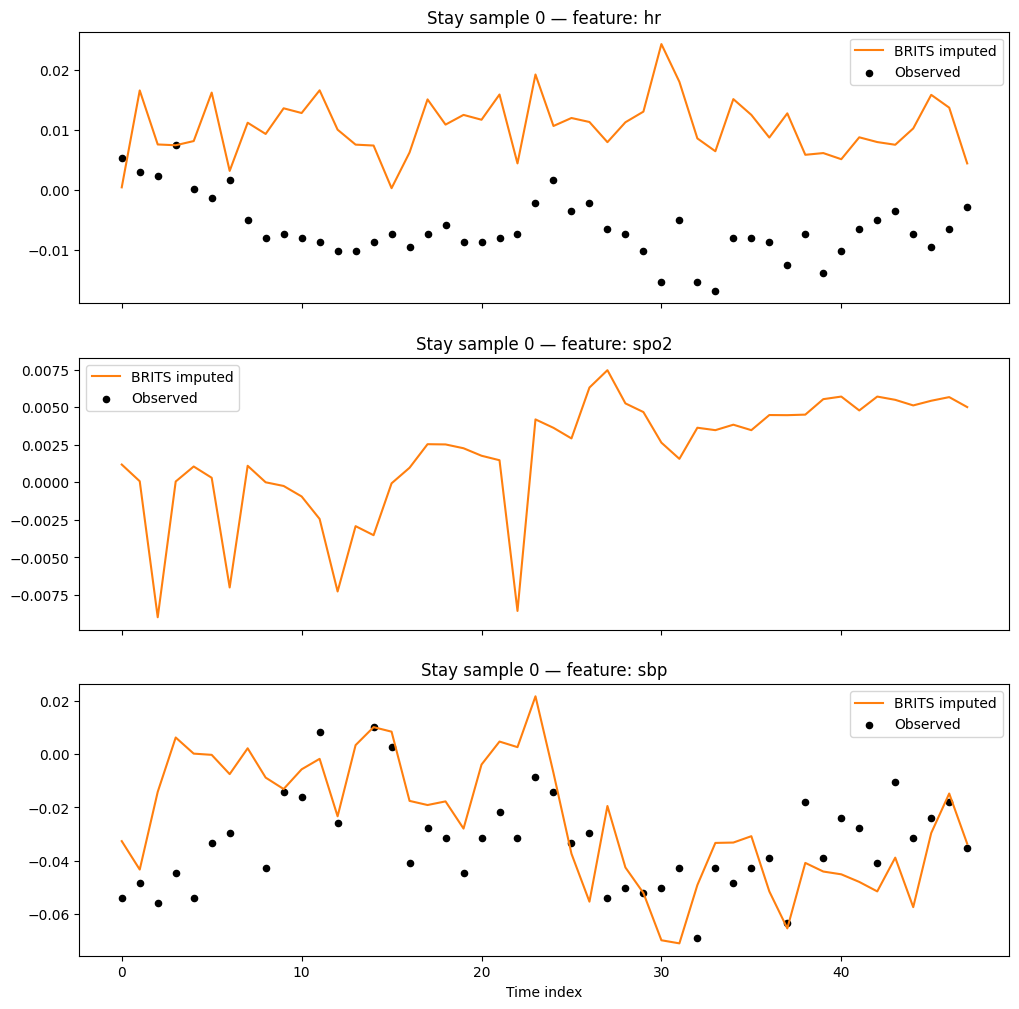

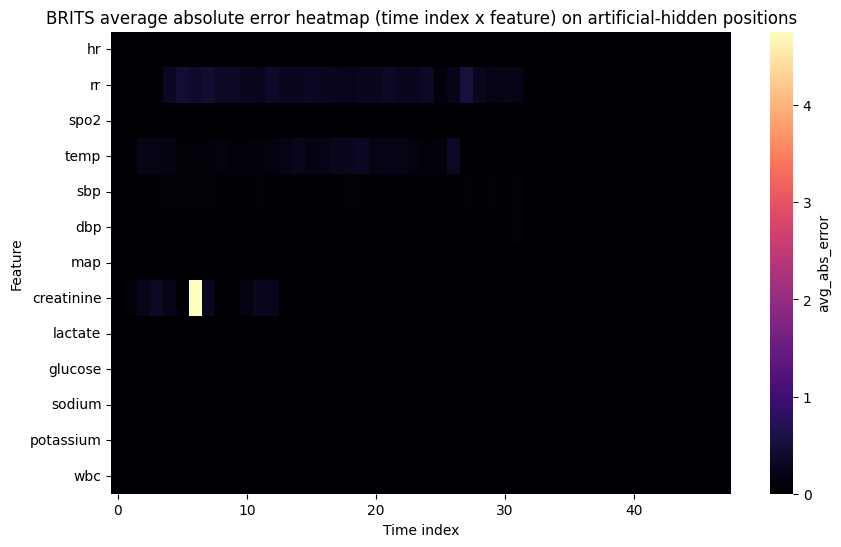

In [ ]:
# Part2 - Cell H: show example imputations and error heatmap
# Get one batch from test_loader
batch = next(iter(test_loader))
x = batch['x']; m = batch['m']
pred_np, hidden, x_np, m_np = impute_batch_brits(brits_model, x, m)

# Convert arrays
B = x_np.shape[0]
# pick first sample with at least one missing position
sample_idx = 0
# time-series plot for selected features (hr, spo2, sbp if present)
sel_feats = ['hr','spo2','sbp']  # change if necessary
fig, axes = plt.subplots(len(sel_feats),1, figsize=(12,4*len(sel_feats)), sharex=True)
t = np.arange(T)
for i,feat in enumerate(sel_feats):
    fi = NUMERIC_FEATURES.index(feat)
    axes[i].plot(t, pred_np[sample_idx,:,fi], label='BRITS imputed', color='C1')
    axes[i].scatter(t[m_np[sample_idx,:,fi]==1], x_np[sample_idx,m_np[sample_idx,:,fi]==1,fi],
                    label='Observed', color='black', s=20)
    axes[i].set_title(f"Stay sample {sample_idx} — feature: {feat}")
    axes[i].legend()
plt.xlabel("Time index")
plt.show()

# Error heatmap using hidden positions across a few batches (aggregate)
# We'll build an error matrix T x D average absolute error over artificially-hidden positions across test set
error_matrix = np.zeros((T,D))
counts = np.zeros((T,D))
# iterate test loader and aggregate
for batch in test_loader:
    x = batch['x']; m = batch['m']
    pred_np, hidden, x_np, m_np = impute_batch_brits(brits_model, x, m)
    for ((b,t,d), gt) in hidden:
        pred_val = pred_np[b,t,d]
        error_matrix[t,d] += abs(pred_val - gt)
        counts[t,d] += 1
# average
avg_error = np.divide(error_matrix, np.maximum(counts, 1))
plt.figure(figsize=(10,6))
sns.heatmap(avg_error.T, cmap='magma', xticklabels=10, yticklabels=NUMERIC_FEATURES, cbar_kws={'label':'avg_abs_error'})
plt.title("BRITS average absolute error heatmap (time index x feature) on artificial-hidden positions")
plt.xlabel("Time index")
plt.ylabel("Feature")
plt.show()


Part 3

In [ ]:
# Part3 Cell 1 — imports & helpers (run if not already imported)
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ensure DEVICE, NUMERIC_FEATURES, T, D are present from earlier parts
print("Device:", DEVICE, "T:", T, "D:", D)


Device: cuda T: 48 D: 13


In [ ]:
# Part3 – Cell 1.5 (ADD THIS BEFORE Cell 2)
# Positional Encoding for SAITS (Transformer-style)

import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)                    # (T, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)          # even dims
        pe[:, 1::2] = torch.cos(position * div_term)          # odd dims

        pe = pe.unsqueeze(0)                                  # (1, T, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: (B, T, d_model)
        """
        T = x.size(1)
        return x + self.pe[:, :T, :]


In [ ]:
# Part3 — Cell 2 (UPDATED)

class SAITSBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            batch_first=True, dropout=dropout
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        attn_out, attn_w = self.attn(
            x, x, x, need_weights=True,
            key_padding_mask=key_padding_mask
        )
        x = self.norm1(x + self.drop(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.drop(ff_out))
        return x, attn_w


class SAITSImputer(nn.Module):
    def __init__(self, input_dim, d_model=128, n_heads=4, n_layers=2, d_ff=256, dropout=0.1):
        super().__init__()
        self.value_proj = nn.Linear(input_dim, d_model)
        self.mask_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model, max_len=T)

        self.blocks = nn.ModuleList([
            SAITSBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.out = nn.Sequential(
            nn.Linear(d_model, d_model//2),
            nn.GELU(),
            nn.Linear(d_model//2, input_dim)
        )

    def forward(self, x, m):
        v = self.value_proj(x)
        mm = self.mask_proj(m)
        h = self.pos(v + mm)

        # Identify completely missing time-steps
        key_padding_mask = (m.sum(dim=-1) == 0)

        attn_maps = []

        for blk in self.blocks:
            h, attn_w = blk(h, key_padding_mask)
            attn_maps.append(attn_w)

        impute = self.out(h)
        fused = m * x + (1 - m) * impute

        return fused, impute, attn_maps


In [ ]:
# Part3 Cell 3 — training utils for SAITS
mse = nn.MSELoss(reduction='none')

def saits_loss(pred, x_true, m_input, hidden_mask_tensor):
    # pred: B x T x D (fused output: observed kept, missing filled)
    # x_true: original GT input (observed values present, missing replaced by 0)
    # m_input: mask used for model input (1 observed, 0 missing)
    # hidden_mask_tensor: positions artificially hidden (1 where hidden)
    # loss components:
    # 1) recon_loss on currently observed positions (m_input==1)
    denom_obs = m_input.sum()
    recon_loss = ((pred - x_true)**2 * m_input).sum() / (denom_obs + 1e-8)
    # 2) imputation_loss on artificially hidden positions
    denom_hidden = hidden_mask_tensor.sum()
    if denom_hidden > 0:
        imp_loss = ((pred - x_true)**2 * hidden_mask_tensor).sum() / denom_hidden
    else:
        imp_loss = torch.tensor(0.0, device=pred.device)
    return recon_loss, imp_loss


In [ ]:
# Part3 Cell 4 — train SAITS
def train_saits(model, train_loader, val_loader, epochs=50, lr=1e-3, hide_fraction=0.12,
                alpha_impute=2.0, device=DEVICE, save_path="saits_best.pth", verbose=True):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best_val = float('inf')
    history = {'train_loss':[], 'val_loss':[], 'train_imp':[], 'val_imp':[]}
    for epoch in range(1, epochs+1):
        model.train()
        train_losses = []; train_imps=[]
        for batch in train_loader:
            x = batch['x'].to(device)
            m = batch['m'].to(device)
            x_art, m_art, hidden = apply_mask(x, m, mode="block")
            hidden_mask = torch.zeros_like(m, device=device)
            for (btd, val) in hidden:
                b,t,d = btd
                hidden_mask[b,t,d] = 1.0
            pred_fused, pred_impute, attn_maps = model(x_art, m_art)
            recon_loss, imp_loss = saits_loss(pred_fused, x, m_art, hidden_mask)
            loss = recon_loss + alpha_impute * imp_loss
            opt.zero_grad(); loss.backward(); opt.step()
            train_losses.append(recon_loss.item() + alpha_impute*imp_loss.item())
            train_imps.append(imp_loss.item())
        # validation
        model.eval()
        val_losses = []; val_imps = []
        with torch.no_grad():
            for batch in val_loader:
                x = batch['x'].to(device); m = batch['m'].to(device)
                x_art, m_art, hidden = apply_mask(x, m, mode="block")
                hidden_mask = torch.zeros_like(m, device=device)
                for (btd, val) in hidden:
                    b,t,d = btd
                    hidden_mask[b,t,d] = 1.0
                pred_fused, pred_impute, attn_maps = model(x_art, m_art)
                recon_loss, imp_loss = saits_loss(pred_fused, x, m_art, hidden_mask)
                val_losses.append(recon_loss.item() + alpha_impute*imp_loss.item())
                val_imps.append(imp_loss.item())
        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses) if len(val_losses)>0 else np.nan
        history['train_loss'].append(avg_train); history['val_loss'].append(avg_val)
        history['train_imp'].append(np.mean(train_imps)); history['val_imp'].append(np.mean(val_imps) if len(val_imps)>0 else np.nan)
        if verbose:
            print(f"[SAITS] Epoch {epoch}/{epochs} train_loss={avg_train:.6f} val_loss={avg_val:.6f} train_imp={history['train_imp'][-1]:.6f} val_imp={history['val_imp'][-1]:.6f}")
        if avg_val < best_val:
            best_val = avg_val
            torch.save(model.state_dict(), save_path)
    model.load_state_dict(torch.load(save_path))
    return model, history


In [ ]:
# Part3 Cell 5 — instantiate & run training
d_model = 128
n_heads = 4
n_layers = 2
d_ff = 256

saits_model = SAITSImputer(input_dim=D, d_model=d_model, n_heads=n_heads, n_layers=n_layers, d_ff=d_ff, dropout=0.1)
# Training hyperparams (adjust for runtime)
SAITS_EPOCHS = 30   # increase if possible
SAITS_LR = 1e-3
HIDE_FRAC = 0.12
ALPHA_IMPUTE = 2.0

saits_model, saits_history = train_saits(
    saits_model, train_loader, val_loader,
    epochs=SAITS_EPOCHS, lr=SAITS_LR, hide_fraction=HIDE_FRAC,
    alpha_impute=ALPHA_IMPUTE, device=DEVICE, save_path="saits_best.pth", verbose=True
)


[SAITS] Epoch 1/30 train_loss=0.287047 val_loss=0.161579 train_imp=0.143523 val_imp=0.080790
[SAITS] Epoch 2/30 train_loss=0.207032 val_loss=0.130724 train_imp=0.103516 val_imp=0.065362
[SAITS] Epoch 3/30 train_loss=0.154625 val_loss=0.106006 train_imp=0.077312 val_imp=0.053003
[SAITS] Epoch 4/30 train_loss=0.170616 val_loss=0.122381 train_imp=0.085308 val_imp=0.061191
[SAITS] Epoch 5/30 train_loss=0.178627 val_loss=0.106789 train_imp=0.089313 val_imp=0.053395
[SAITS] Epoch 6/30 train_loss=0.163563 val_loss=0.097553 train_imp=0.081781 val_imp=0.048777
[SAITS] Epoch 7/30 train_loss=0.243777 val_loss=0.096138 train_imp=0.121889 val_imp=0.048069
[SAITS] Epoch 8/30 train_loss=0.146729 val_loss=0.110132 train_imp=0.073365 val_imp=0.055066
[SAITS] Epoch 9/30 train_loss=0.158292 val_loss=0.101773 train_imp=0.079146 val_imp=0.050886
[SAITS] Epoch 10/30 train_loss=0.171107 val_loss=0.095584 train_imp=0.085554 val_imp=0.047792
[SAITS] Epoch 11/30 train_loss=0.130132 val_loss=0.117275 train_imp=0

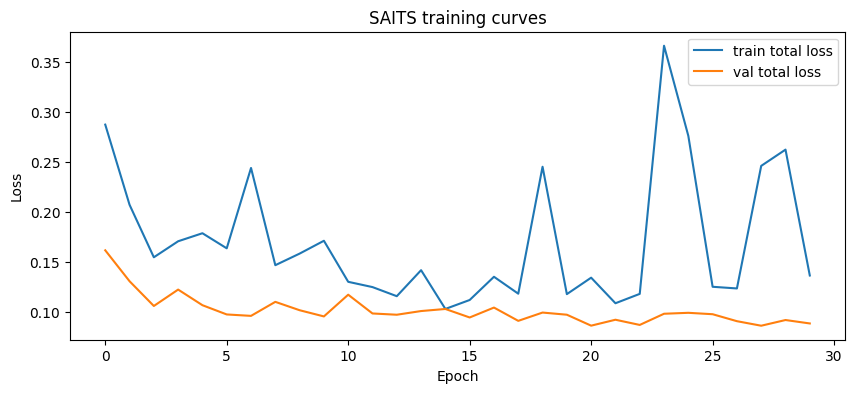

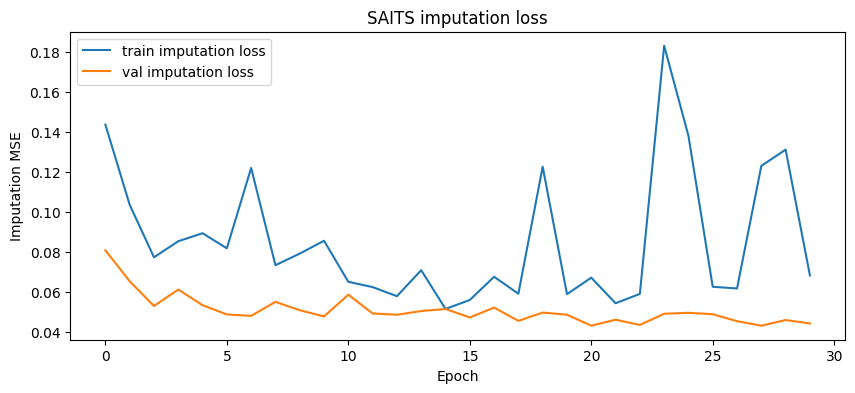

In [ ]:
# Part3 Cell 6 — plot training curves
plt.figure(figsize=(10,4))
plt.plot(saits_history['train_loss'], label='train total loss')
plt.plot(saits_history['val_loss'], label='val total loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('SAITS training curves'); plt.legend(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(saits_history['train_imp'], label='train imputation loss')
plt.plot(saits_history['val_imp'], label='val imputation loss')
plt.xlabel('Epoch'); plt.ylabel('Imputation MSE'); plt.title('SAITS imputation loss'); plt.legend(); plt.show()


In [ ]:
# Part3 Cell 7 — evaluate SAITS with artificial masking
def evaluate_model_on_test_imputation(model, loader, hide_fraction=0.12):
    model.eval()
    preds_all = []
    gts = []
    pred_vals = []
    gt_vals = []
    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(DEVICE); m = batch['m'].to(DEVICE)
            x_art, m_art, hidden = apply_mask(x, m, mode="block")
            pred_fused, pred_impute, attn_maps = model(x_art, m_art)
            pred_np = pred_fused.cpu().numpy()
            x_np = x.cpu().numpy()
            for ((b,t,d), gt) in hidden:
                pred_val = pred_np[b,t,d]
                pred_vals.append(pred_val)
                gt_vals.append(gt)
    if len(gt_vals)==0:
        return {'rmse':np.nan, 'mae':np.nan, 'r2':np.nan, 'n':0}
    rmse = np.sqrt(mean_squared_error(gt_vals, pred_vals))
    mae = mean_absolute_error(gt_vals, pred_vals)
    r2 = r2_score(gt_vals, pred_vals)
    return {'rmse':rmse, 'mae':mae, 'r2':r2, 'n':len(gt_vals)}

saits_metrics = evaluate_model_on_test_imputation(saits_model, test_loader, hide_fraction=0.12)
print("SAITS evaluation on artificial-hidden test positions:", saits_metrics)

# If you saved BRITS metrics earlier (from Part2), print them for side-by-side comparison
try:
    print("BRITS metrics from Part2 (if computed):", "{use saved values you computed earlier}")
except:
    pass


SAITS evaluation on artificial-hidden test positions: {'rmse': np.float64(0.2315034370367183), 'mae': 0.1059964887654774, 'r2': 0.5935540182755545, 'n': 3430}
BRITS metrics from Part2 (if computed): {use saved values you computed earlier}


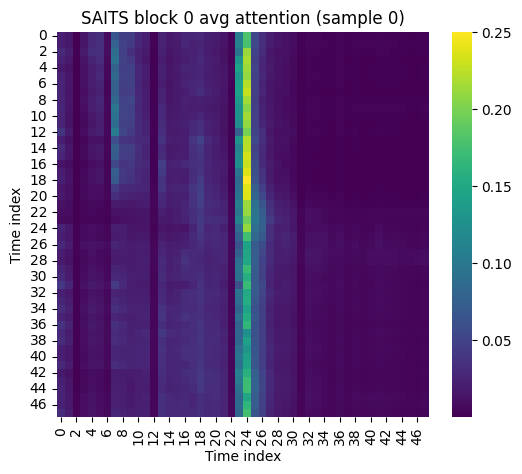

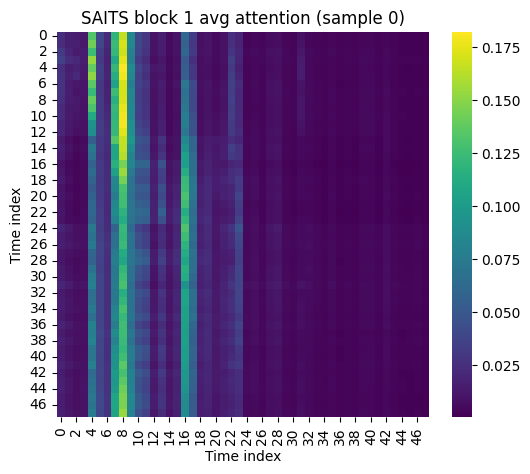

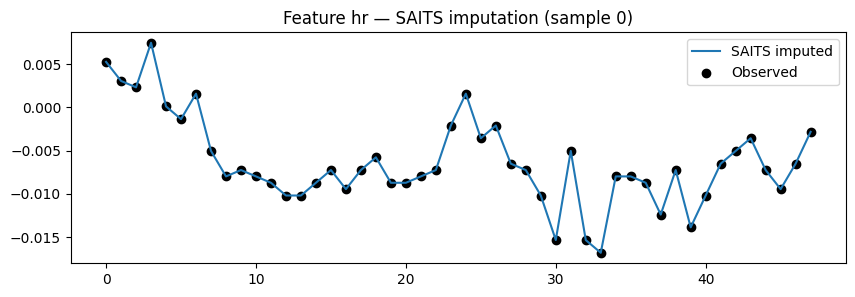

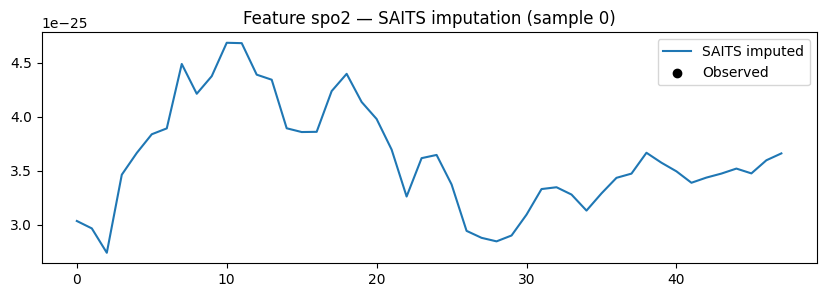

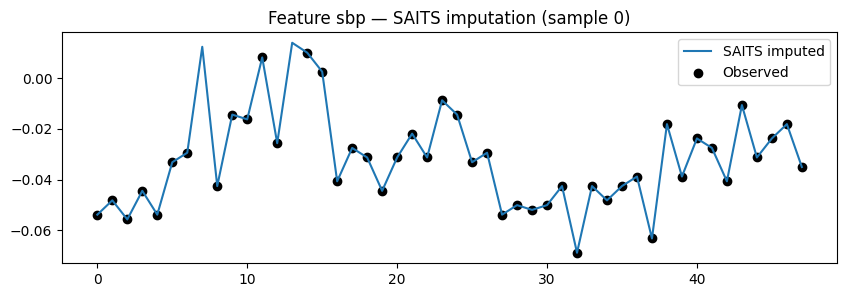

In [ ]:
# Part3 Cell 8 — get attention maps for sample batch and plot
batch = next(iter(test_loader))
x = batch['x'].to(DEVICE); m = batch['m'].to(DEVICE)
saits_model.eval()
with torch.no_grad():
    fused, impute_out, attn_maps = saits_model(x, m)
# attn_maps is a list of attention tensors for each block; each attention may be (B, n_heads, T, T) or different
# We'll attempt to aggregate per-block average attention over heads for the first sample in batch
first_sample = 0
for blk_idx, attn in enumerate(attn_maps):
    # attn may be a tensor with shape (B, n_heads, T, T) or (B, T, T) depending on PyTorch version.
    att = attn.detach().cpu().numpy()
    # try to make it shape (B, n_heads, T, T)
    if att.ndim == 3:
        # (B, T, T) -> add head dim =1
        att = att[:, np.newaxis, :, :]
    # average over heads for sample 0
    avg_att = np.mean(att[first_sample], axis=0)  # T x T
    plt.figure(figsize=(6,5))
    sns.heatmap(avg_att, cmap='viridis')
    plt.title(f"SAITS block {blk_idx} avg attention (sample {first_sample})")
    plt.xlabel("Time index"); plt.ylabel("Time index")
    plt.show()

# Per-feature time series imputation example for first sample (show 3 features)
sample_np = fused.cpu().numpy()
x_np = x.cpu().numpy()
m_np = m.cpu().numpy()
sel_feats = ['hr','spo2','sbp']
t = np.arange(T)
for feat in sel_feats:
    fi = NUMERIC_FEATURES.index(feat)
    plt.figure(figsize=(10,3))
    plt.plot(t, sample_np[first_sample,:,fi], label='SAITS imputed', linewidth=1.5)
    plt.scatter(t[m_np[first_sample,:,fi]==1], x_np[first_sample,m_np[first_sample,:,fi]==1,fi], label='Observed', color='k')
    plt.title(f"Feature {feat} — SAITS imputation (sample {first_sample})")
    plt.legend()
    plt.show()


G-Series

In [ ]:
# G1 - imports & device check (run if needed)
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Device:", DEVICE)


Device: cuda


In [ ]:
# G2 — GAIN Generator & Discriminator (Stable)
class GAIN_Generator(nn.Module):
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(input_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, m, z):
        inp = torch.cat([x, z], dim=-1)
        h = torch.relu(self.fc1(inp))
        h = torch.relu(self.fc2(h))
        raw_out = self.fc3(h)              # <-- no sigmoid
        imputed = m * x + (1 - m) * raw_out
        return imputed


class GAIN_Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(input_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x_hat, m):
        inp = torch.cat([x_hat, m], dim=-1)
        h = torch.relu(self.fc1(inp))
        h = torch.relu(self.fc2(h))
        logits = self.fc3(h)
        return torch.sigmoid(logits)  # probability per feature


In [ ]:
# G3 — GAIN losses
bce_loss = nn.BCELoss()

def gain_discriminator_loss(D_prob, m):
    return bce_loss(D_prob, m)

def gain_generator_loss(D_prob, m, x_hat, x, m_art, lambda_mse=10.0):
    adv = bce_loss(D_prob, torch.ones_like(D_prob))
    mse = ((x_hat - x)**2 * (1 - m_art)).sum() / ((1 - m_art).sum() + 1e-8)
    return adv + lambda_mse * mse


In [ ]:
# G4 — Training loop for GAIN (UPDATED with gradient clipping)

def train_gain(G, D, train_loader, val_loader=None, epochs=40, lr=1e-4, hide_fraction=0.12, device=DEVICE):
    G = G.to(device)
    D = D.to(device)

    g_opt = optim.Adam(G.parameters(), lr=lr)
    d_opt = optim.Adam(D.parameters(), lr=lr)

    history = {'g_loss': [], 'd_loss': []}

    for epoch in range(1, epochs+1):
        G.train(); D.train()
        g_losses = []; d_losses = []

        for batch in train_loader:
            x = batch['x'].to(device)
            m = batch['m'].to(device)

            x_art, m_art, hidden = apply_mask(x, m, mode="block")
            z = torch.rand_like(x_art).to(device)

            # ---- Train Discriminator ----
            d_opt.zero_grad()
            x_hat = G(x_art, m_art, z).detach()
            D_prob = D(x_hat, m_art)
            d_loss = gain_discriminator_loss(D_prob, m_art)
            d_loss.backward()

            # 🔥 Gradient clipping added
            torch.nn.utils.clip_grad_norm_(D.parameters(), 5.0)

            d_opt.step()
            d_losses.append(d_loss.item())

            # ---- Train Generator ----
            g_opt.zero_grad()
            x_hat = G(x_art, m_art, z)
            D_prob = D(x_hat, m_art)
            g_loss = gain_generator_loss(D_prob, m_art, x_hat, x, m_art)
            g_loss.backward()

            # 🔥 Gradient clipping added
            torch.nn.utils.clip_grad_norm_(G.parameters(), 5.0)

            g_opt.step()
            g_losses.append(g_loss.item())

        print(f"[GAIN] Epoch {epoch}/{epochs} G_loss={np.mean(g_losses):.4f} D_loss={np.mean(d_losses):.4f}")
        history['g_loss'].append(np.mean(g_losses))
        history['d_loss'].append(np.mean(d_losses))

    return G, D, history


In [ ]:
# G5 — instantiate & train GAIN
gain_G = GAIN_Generator(input_dim=D, hidden_dim=256)
gain_D = GAIN_Discriminator(input_dim=D, hidden_dim=256)

GAIN_EPOCHS = 40

gain_G, gain_D, gain_history = train_gain(
    gain_G, gain_D, train_loader, val_loader,
    epochs=GAIN_EPOCHS, lr=1e-4, hide_fraction=0.12, device=DEVICE
)


[GAIN] Epoch 1/40 G_loss=0.7741 D_loss=0.6532
[GAIN] Epoch 2/40 G_loss=0.8842 D_loss=0.5499
[GAIN] Epoch 3/40 G_loss=1.1712 D_loss=0.4190
[GAIN] Epoch 4/40 G_loss=1.5415 D_loss=0.3274
[GAIN] Epoch 5/40 G_loss=1.8363 D_loss=0.2654
[GAIN] Epoch 6/40 G_loss=2.0920 D_loss=0.2121
[GAIN] Epoch 7/40 G_loss=2.3593 D_loss=0.1657
[GAIN] Epoch 8/40 G_loss=2.6576 D_loss=0.1283
[GAIN] Epoch 9/40 G_loss=2.9330 D_loss=0.0998
[GAIN] Epoch 10/40 G_loss=3.1826 D_loss=0.0791
[GAIN] Epoch 11/40 G_loss=3.4120 D_loss=0.0634
[GAIN] Epoch 12/40 G_loss=3.6223 D_loss=0.0521
[GAIN] Epoch 13/40 G_loss=3.8085 D_loss=0.0438
[GAIN] Epoch 14/40 G_loss=3.9777 D_loss=0.0374
[GAIN] Epoch 15/40 G_loss=4.1361 D_loss=0.0328
[GAIN] Epoch 16/40 G_loss=4.2762 D_loss=0.0286
[GAIN] Epoch 17/40 G_loss=4.4275 D_loss=0.0251
[GAIN] Epoch 18/40 G_loss=4.5617 D_loss=0.0225
[GAIN] Epoch 19/40 G_loss=4.6786 D_loss=0.0202
[GAIN] Epoch 20/40 G_loss=4.8052 D_loss=0.0182
[GAIN] Epoch 21/40 G_loss=4.9199 D_loss=0.0165
[GAIN] Epoch 22/40 G_l

In [ ]:
# G6 — evaluation GAIN
def evaluate_gain(G, loader, hide_fraction=0.12):
    pred_vals = []
    gt_vals = []

    G.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(DEVICE)
            m = batch['m'].to(DEVICE)

            x_art, m_art, hidden = apply_mask(x, m, mode="block")
            z = torch.rand_like(x_art).to(DEVICE)

            x_hat = G(x_art, m_art, z)
            x_hat_np = x_hat.cpu().numpy()
            x_np = x.cpu().numpy()

            for ((b,t,d), gt) in hidden:
                pred_vals.append(x_hat_np[b,t,d])
                gt_vals.append(gt)

    rmse = np.sqrt(mean_squared_error(gt_vals, pred_vals))
    mae = mean_absolute_error(gt_vals, pred_vals)
    r2 = r2_score(gt_vals, pred_vals)

    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'n': len(gt_vals)}

gain_metrics = evaluate_gain(gain_G, test_loader)
print("GAIN Metrics:", gain_metrics)


GAIN Metrics: {'rmse': np.float64(0.3716705207938338), 'mae': 0.18954317139654417, 'r2': -0.04762096355101786, 'n': 3430}


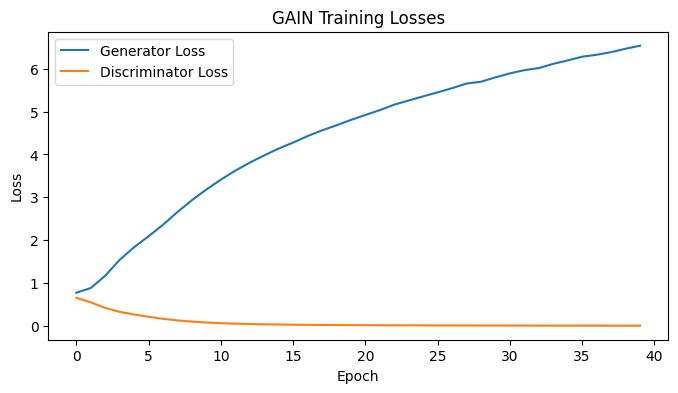

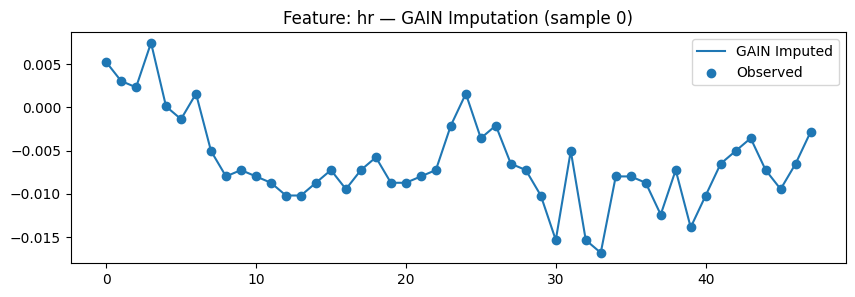

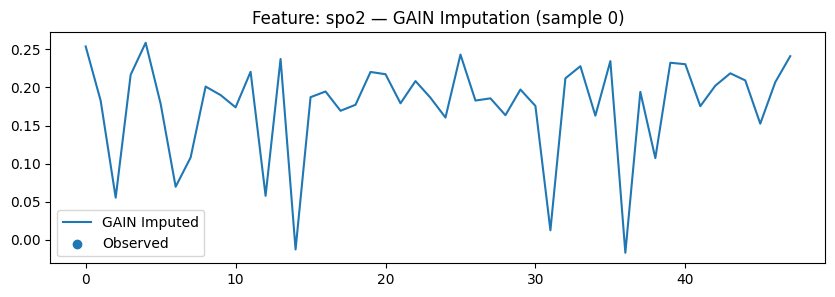

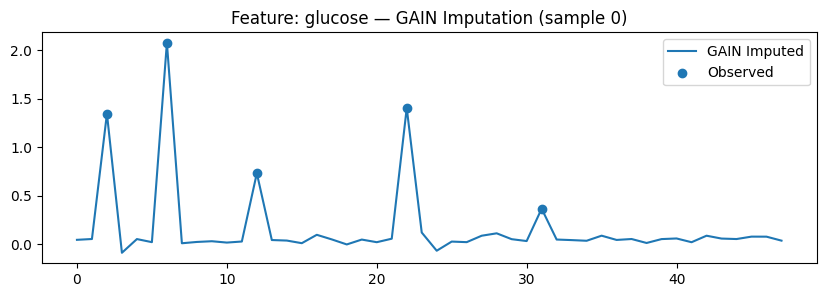

In [ ]:
# G7 — Visualizations for GAIN

# ---- 1) Plot Generator & Discriminator losses ----
plt.figure(figsize=(8,4))
plt.plot(gain_history['g_loss'], label='Generator Loss')
plt.plot(gain_history['d_loss'], label='Discriminator Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAIN Training Losses")
plt.legend()
plt.show()

# ---- 2) Visualize example imputations ----

batch = next(iter(test_loader))
x = batch['x'].to(DEVICE)
m = batch['m'].to(DEVICE)

with torch.no_grad():
    z = torch.rand_like(x).to(DEVICE)
    x_hat = gain_G(x, m, z)

x_np = x.cpu().numpy()
x_hat_np = x_hat.cpu().numpy()
m_np = m.cpu().numpy()

sample = 0
features_to_plot = ['hr', 'spo2', 'glucose']  # modify if needed

for feat in features_to_plot:
    fi = NUMERIC_FEATURES.index(feat)
    t = np.arange(T)

    plt.figure(figsize=(10,3))
    plt.plot(t, x_hat_np[sample,:,fi], label='GAIN Imputed')
    plt.scatter(
        t[m_np[sample,:,fi] == 1],
        x_np[sample,m_np[sample,:,fi] == 1,fi],
        label='Observed',
    )
    plt.title(f"Feature: {feat} — GAIN Imputation (sample {sample})")
    plt.legend()
    plt.show()


F-Series

In [ ]:
# --------------------------
# F1 - Fusion network (cell F1)
# --------------------------
import torch
import torch.nn as nn

class FusionNet(nn.Module):
    """
    Per-time-step, per-feature fusion: learns 3 weights (BRITS, SAITS, GAN) per time-feature,
    then forms convex combination (softmax over 3).
    Inputs:
      - brits_pred, saits_pred, gan_pred: each (B, T, D) (normalized)
    Outputs:
      - fused: (B, T, D)
      - weights: (B, T, 3, D)  (softmaxed across the 3 models)
    """
    def __init__(self, input_dim, hidden=128, time_len=None):
        super().__init__()
        self.input_dim = input_dim
        self.mlp = nn.Sequential(
            nn.Linear(3 * input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 3 * input_dim)
        )

    def forward(self, brits_pred, saits_pred, gan_pred):
        # brits_pred / saits_pred / gan_pred: B x T x D
        B, T, D = brits_pred.shape
        concat = torch.cat([brits_pred, saits_pred, gan_pred], dim=-1)  # B x T x (3D)
        out = self.mlp(concat)  # B x T x (3D)
        out = out.view(B, T, 3, D)  # B x T x 3 x D
        weights = torch.softmax(out, dim=2)  # softmax over the 3 models (axis=2)
        stacked = torch.stack([brits_pred, saits_pred, gan_pred], dim=2)  # B x T x 3 x D
        fused = (weights * stacked).sum(dim=2)  # B x T x D
        return fused, weights


In [ ]:
# --------------------------
# F2 — train_fusion_attention (UPDATED)
# --------------------------
import numpy as np
import torch
import torch.optim as optim

def train_fusion_attention(fusion_model, brits_model, saits_model, gen_model,
                           train_loader, val_loader,
                           epochs=20, lr=1e-3, hide_fraction=0.12,
                           device=DEVICE, save_path="fusion_best.pth",
                           entropy_coef=0.01, clip_grad=5.0):
    """
    Train only the fusion_model while keeping brits_model, saits_model, gen_model frozen.
    Loss = MSE on artificially-hidden positions + (entropy_coef * entropy(weights))
    """
    # freeze the component models
    for p in brits_model.parameters(): p.requires_grad = False
    for p in saits_model.parameters(): p.requires_grad = False
    for p in gen_model.parameters(): p.requires_grad = False

    brits_model.eval(); saits_model.eval(); gen_model.eval()

    fusion_model = fusion_model.to(device)
    opt = optim.Adam(fusion_model.parameters(), lr=lr, weight_decay=1e-5)
    best_val = float('inf')
    history = {'train_loss':[], 'val_loss':[]}

    for epoch in range(1, epochs+1):
        fusion_model.train()
        train_losses = []

        for batch in train_loader:
            x = batch['x'].to(device)
            m = batch['m'].to(device)

            # artificial hiding
            x_art, m_art, hidden = apply_mask(x, m, mode="block")
            # build hidden mask tensor
            hidden_mask = torch.zeros_like(m, device=device)
            for (btd, _) in hidden:
                b,t,d = btd
                hidden_mask[b,t,d] = 1.0

            # if no hidden positions in this batch, skip
            denom = hidden_mask.sum()
            if denom == 0:
                continue

            # get component predictions from frozen models
            with torch.no_grad():
                brits_pred, _, _ = brits_model(x_art, m_art)     # B x T x D
                saits_pred, _, _ = saits_model(x_art, m_art)     # B x T x D
                z = torch.randn_like(x_art).to(device) * 0.1
                gan_pred = gen_model(x_art, m_art, z)            # B x T x D

            # forward fusion
            fused, weights = fusion_model(brits_pred, saits_pred, gan_pred)

            # MSE loss on artificially hidden positions
            mse_loss = ((fused - x)**2 * hidden_mask).sum() / (denom + 1e-8)

            # entropy regularization to avoid always picking one model (mean over batch/time/feature)
            epsilon = 1e-12
            entropy = - (weights * (weights + epsilon).log()).sum(dim=2).mean()  # scalar

            loss = mse_loss + entropy_coef * entropy

            opt.zero_grad()
            loss.backward()

            # gradient clipping
            if clip_grad is not None:
                torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), clip_grad)

            opt.step()
            train_losses.append(loss.item())

        avg_train = np.mean(train_losses) if len(train_losses)>0 else np.nan

        # validation (no entropy reg)
        fusion_model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                x = batch['x'].to(device)
                m = batch['m'].to(device)

                x_art, m_art, hidden = apply_mask(x, m, mode="block")
                hidden_mask = torch.zeros_like(m, device=device)
                for (btd, _) in hidden:
                    b,t,d = btd
                    hidden_mask[b,t,d] = 1.0

                denom = hidden_mask.sum()
                if denom == 0:
                    continue

                brits_pred, _, _ = brits_model(x_art, m_art)
                saits_pred, _, _ = saits_model(x_art, m_art)
                z = torch.randn_like(x_art).to(device) * 0.1
                gan_pred = gen_model(x_art, m_art, z)

                fused, weights = fusion_model(brits_pred, saits_pred, gan_pred)
                loss = ((fused - x)**2 * hidden_mask).sum() / (denom + 1e-8)
                val_losses.append(loss.item())

        avg_val = np.mean(val_losses) if len(val_losses)>0 else np.nan
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        print(f"[FUSION] Epoch {epoch}/{epochs} train={avg_train:.6f}  val={avg_val:.6f}")

        if not np.isnan(avg_val) and avg_val < best_val:
            best_val = avg_val
            torch.save(fusion_model.state_dict(), save_path)

    # load best
    if os.path.exists(save_path):
        fusion_model.load_state_dict(torch.load(save_path, map_location=device))
    return fusion_model, history


In [ ]:
# --------------------------
# F3 - instantiate fusion net and train (cell F3)
# --------------------------
fusion_model = FusionNet(input_dim=D, hidden=128, time_len=T)
F_EPOCHS = 20

fusion_model, fusion_history = train_fusion_attention(
    fusion_model=fusion_model,
    brits_model=brits_model,
    saits_model=saits_model,
    gen_model=gain_G,       # trained GAIN generator
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=F_EPOCHS,
    lr=1e-3,
    hide_fraction=0.12,
    device=DEVICE,
    save_path="fusion_best.pth",
    entropy_coef=0.01,
    clip_grad=5.0
)


[FUSION] Epoch 1/20 train=0.077617  val=0.047712
[FUSION] Epoch 2/20 train=0.063657  val=0.045546
[FUSION] Epoch 3/20 train=0.135921  val=0.044605
[FUSION] Epoch 4/20 train=0.051139  val=0.044542
[FUSION] Epoch 5/20 train=0.068281  val=0.044429
[FUSION] Epoch 6/20 train=0.063507  val=0.044307
[FUSION] Epoch 7/20 train=0.053456  val=0.044048
[FUSION] Epoch 8/20 train=0.074821  val=0.043845
[FUSION] Epoch 9/20 train=0.098680  val=0.043746
[FUSION] Epoch 10/20 train=0.056602  val=0.044039
[FUSION] Epoch 11/20 train=0.074770  val=0.044077
[FUSION] Epoch 12/20 train=0.049012  val=0.044363
[FUSION] Epoch 13/20 train=0.053385  val=0.044318
[FUSION] Epoch 14/20 train=0.061448  val=0.044387
[FUSION] Epoch 15/20 train=0.057752  val=0.044357
[FUSION] Epoch 16/20 train=0.058555  val=0.044378
[FUSION] Epoch 17/20 train=0.056260  val=0.044377
[FUSION] Epoch 18/20 train=0.052413  val=0.044272
[FUSION] Epoch 19/20 train=0.081219  val=0.044128
[FUSION] Epoch 20/20 train=0.112580  val=0.044279


In [ ]:
# ==================================================
# FINE-TUNING: Fusion-Aware Joint Optimization
# ==================================================

import torch
import torch.optim as optim
import numpy as np

print("🔧 Starting fusion-aware fine-tuning...")

# --------------------------------------------------
# 1️⃣ Freeze EVERYTHING first
# --------------------------------------------------
for model in [brits_model, saits_model, gain_G]:
    for p in model.parameters():
        p.requires_grad = False

# --------------------------------------------------
# 2️⃣ Unfreeze ONLY top layers (safe fine-tuning)
# --------------------------------------------------

# BRITS: output projection
for p in brits_model.fc.parameters():
    p.requires_grad = True

# SAITS: output head
for p in saits_model.out.parameters():
    p.requires_grad = True

# FusionNet stays trainable
for p in fusion_model.parameters():
    p.requires_grad = True

# --------------------------------------------------
# 3️⃣ Optimizer (VERY SMALL LR)
# --------------------------------------------------
FT_LR = 5e-5
FT_EPOCHS = 8

optimizer = optim.Adam(
    list(brits_model.fc.parameters()) +
    list(saits_model.out.parameters()) +
    list(fusion_model.parameters()),
    lr=FT_LR
)

print("✅ Trainable parameters:")
print("BRITS fc:", sum(p.requires_grad for p in brits_model.parameters()))
print("SAITS out:", sum(p.requires_grad for p in saits_model.parameters()))
print("Fusion:", sum(p.requires_grad for p in fusion_model.parameters()))

# --------------------------------------------------
# 4️⃣ Fine-tuning loop (hidden-position loss only)
# --------------------------------------------------
fusion_model.train()
brits_model.train()
saits_model.train()

for epoch in range(1, FT_EPOCHS + 1):
    losses = []

    for batch in train_loader:
        x = batch['x'].to(DEVICE)
        m = batch['m'].to(DEVICE)

        # Artificial block masking
        x_art, m_art, hidden = apply_mask(x, m, mode="block")

        if len(hidden) == 0:
            continue

        hidden_mask = torch.zeros_like(m)
        for (b, t, d), _ in hidden:
            hidden_mask[b, t, d] = 1.0

        # Forward passes
        brits_pred, _, _ = brits_model(x_art, m_art)
        saits_pred, _, _ = saits_model(x_art, m_art)

        z = torch.randn_like(x_art).to(DEVICE) * 0.1
        gan_pred = gain_G(x_art, m_art, z)

        fused_pred, _ = fusion_model(brits_pred, saits_pred, gan_pred)

        # Loss ONLY on artificially hidden entries
        denom = hidden_mask.sum()
        loss = ((fused_pred - x) ** 2 * hidden_mask).sum() / (denom + 1e-8)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(brits_model.fc.parameters()) +
            list(saits_model.out.parameters()) +
            list(fusion_model.parameters()),
            3.0
        )

        optimizer.step()
        losses.append(loss.item())

    print(f"[Fine-Tune] Epoch {epoch}/{FT_EPOCHS} loss={np.mean(losses):.6f}")

print("✅ Fusion-aware fine-tuning complete!")


🔧 Starting fusion-aware fine-tuning...
✅ Trainable parameters:
BRITS fc: 2
SAITS out: 4
Fusion: 4
[Fine-Tune] Epoch 1/8 loss=0.055511
[Fine-Tune] Epoch 2/8 loss=0.054718
[Fine-Tune] Epoch 3/8 loss=0.055222
[Fine-Tune] Epoch 4/8 loss=0.058040
[Fine-Tune] Epoch 5/8 loss=0.112898
[Fine-Tune] Epoch 6/8 loss=0.163452
[Fine-Tune] Epoch 7/8 loss=0.112162
[Fine-Tune] Epoch 8/8 loss=0.051030
✅ Fusion-aware fine-tuning complete!


In [ ]:
# --------------------------
# F4 - evaluation comparing BRITS, SAITS, GAN, Fusion (SINGLE FINAL CELL)
# --------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch

def eval_all_models(
    brits_model,
    saits_model,
    gen_model,
    fusion_model,
    loader,
    missing_mode="block",
    device=DEVICE
):
    results = {'brits': [], 'saits': [], 'gan': [], 'fusion': []}
    gt_vals = []

    brits_model.eval()
    saits_model.eval()
    gen_model.eval()
    fusion_model.eval()

    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(device)
            m = batch['m'].to(device)

            # ✅ unified masking (point / subsequence / block)
            x_art, m_art, hidden = apply_mask(x, m, mode=missing_mode)

            if len(hidden) == 0:
                continue

            # model predictions
            brits_pred, _, _ = brits_model(x_art, m_art)
            saits_pred, _, _ = saits_model(x_art, m_art)

            z = torch.randn_like(x_art).to(device) * 0.1
            gan_pred = gen_model(x_art, m_art, z)

            fusion_pred, _ = fusion_model(brits_pred, saits_pred, gan_pred)

            # to numpy
            brits_np = brits_pred.cpu().numpy()
            saits_np = saits_pred.cpu().numpy()
            gan_np = gan_pred.cpu().numpy()
            fusion_np = fusion_pred.cpu().numpy()

            for ((b, t, d), gt) in hidden:
                results['brits'].append(brits_np[b, t, d])
                results['saits'].append(saits_np[b, t, d])
                results['gan'].append(gan_np[b, t, d])
                results['fusion'].append(fusion_np[b, t, d])
                gt_vals.append(gt)

    metrics = {}
    for k in results:
        preds = results[k]
        if len(preds) == 0:
            metrics[k] = {'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n': 0}
        else:
            metrics[k] = {
                'rmse': np.sqrt(mean_squared_error(gt_vals, preds)),
                'mae': mean_absolute_error(gt_vals, preds),
                'r2': r2_score(gt_vals, preds),
                'n': len(preds)
            }

    rmse_list = [metrics['brits']['rmse'], metrics['saits']['rmse'], metrics['gan']['rmse']]
    best_single_rmse = np.nanmin(rmse_list)
    fusion_rmse = metrics['fusion']['rmse']

    if not np.isnan(fusion_rmse) and best_single_rmse > 0:
        metrics['percent_improvement'] = (best_single_rmse - fusion_rmse) / best_single_rmse * 100.0
    else:
        metrics['percent_improvement'] = np.nan

    return metrics


# --------------------------
# RUN EVALUATION
# --------------------------
metrics_all = eval_all_models(
    brits_model=brits_model,
    saits_model=saits_model,
    gen_model=gain_G,
    fusion_model=fusion_model,
    loader=test_loader,
    missing_mode="block",   # change to "point" or "subsequence" if needed
    device=DEVICE
)

print("Final comparison metrics (artificial-hidden test set):")
for k, v in metrics_all.items():
    if k != 'percent_improvement':
        print(f"{k}: RMSE={v['rmse']:.4f} MAE={v['mae']:.4f} R2={v['r2']:.4f} n={v['n']}")
print("Percent improvement of Fusion (RMSE) over best single:",
      metrics_all['percent_improvement'])


Final comparison metrics (artificial-hidden test set):
brits: RMSE=0.2285 MAE=0.1100 R2=0.6039 n=3430
saits: RMSE=0.2270 MAE=0.1014 R2=0.6090 n=3430
gan: RMSE=0.3726 MAE=0.1840 R2=-0.0531 n=3430
fusion: RMSE=0.2189 MAE=0.0993 R2=0.6367 n=3430
Percent improvement of Fusion (RMSE) over best single: 3.600720959055232


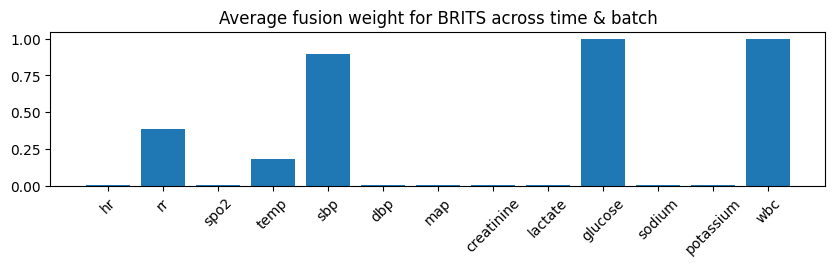

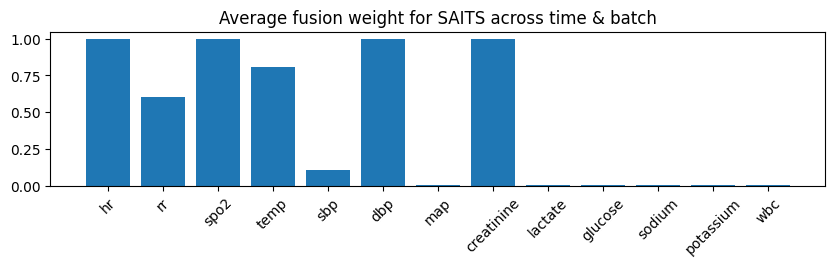

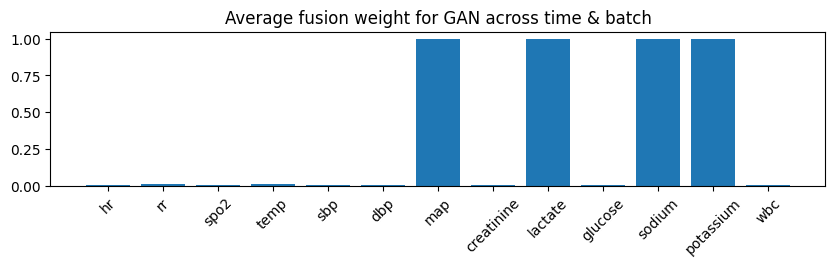

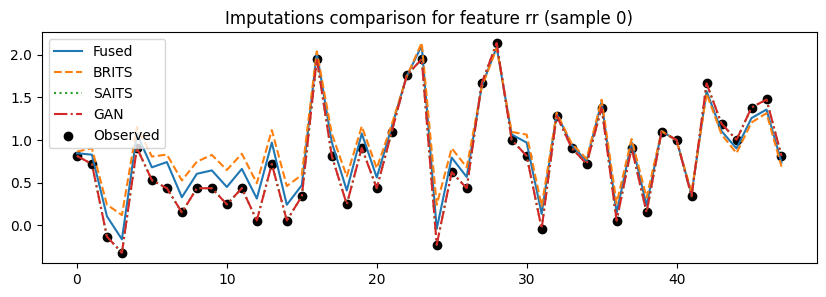

In [ ]:
# --------------------------
# F5 - visualize fusion weights & example (cell F5)
# --------------------------
import matplotlib.pyplot as plt
import numpy as np

# get one batch
batch = next(iter(test_loader))
x = batch['x'].to(DEVICE); m = batch['m'].to(DEVICE)

with torch.no_grad():
    brits_pred,_,_ = brits_model(x, m)
    saits_pred,_,_ = saits_model(x, m)
    z = torch.randn_like(x).to(DEVICE) * 0.1
    gen_out = gain_G(x, m, z)            # use trained generator
    gan_pred = gen_out
    fused, weights = fusion_model(brits_pred, saits_pred, gan_pred)

# weights: B x T x 3 x D -> convert to numpy safely
weights_np = weights.detach().cpu().numpy()
# average across batch and time -> (3, D)
avg_weights_feature = weights_np.mean(axis=1).mean(axis=0)  # shape (3, D)

for model_idx, name in enumerate(['BRITS','SAITS','GAN']):
    plt.figure(figsize=(10,2))
    plt.bar(NUMERIC_FEATURES, avg_weights_feature[model_idx])
    plt.title(f"Average fusion weight for {name} across time & batch")
    plt.xticks(rotation=45)
    plt.show()

# example: fused vs components for a single sample & feature
sample = 0
feat = 'rr'
fi = NUMERIC_FEATURES.index(feat)
t = np.arange(T)

plt.figure(figsize=(10,3))
plt.plot(t, fused.cpu().numpy()[sample,:,fi], label='Fused', linewidth=1.5)
plt.plot(t, brits_pred.cpu().numpy()[sample,:,fi], label='BRITS', linestyle='--')
plt.plot(t, saits_pred.cpu().numpy()[sample,:,fi], label='SAITS', linestyle=':')
plt.plot(t, gan_pred.cpu().numpy()[sample,:,fi], label='GAN', linestyle='-.')
plt.scatter(t[m.cpu().numpy()[sample,:,fi]==1],
            x.cpu().numpy()[sample,m.cpu().numpy()[sample,:,fi]==1,fi],
            color='k', label='Observed')
plt.legend(); plt.title(f"Imputations comparison for feature {feat} (sample {sample})"); plt.show()


Alternating Attention Imputation (AAI) model

In [ ]:
import torch
import torch.nn as nn

class AlternatingAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        # Temporal attention (over time dimension)
        self.temp_attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )

        # Variable attention (global feature context)
        self.var_attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

        self.drop = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        """
        x: (B, T, d_model)
        """

        # 1️⃣ Temporal attention
        temp_out, _ = self.temp_attn(
            x, x, x, key_padding_mask=key_padding_mask
        )
        x = self.norm1(x + self.drop(temp_out))

        # 2️⃣ Variable attention (global, safe)
        var_token = x.mean(dim=1, keepdim=True)  # (B, 1, d_model)
        var_out, _ = self.var_attn(var_token, var_token, var_token)
        var_out = var_out.repeat(1, x.size(1), 1)  # (B, T, d_model)

        x = self.norm2(x + self.drop(var_out))

        # 3️⃣ Feedforward
        ff_out = self.ff(x)
        x = self.norm3(x + self.drop(ff_out))

        return x


In [ ]:
class AlternatingAttentionImputer(nn.Module):
    def __init__(self, input_dim, d_model=128, n_heads=4, n_layers=2, d_ff=256):
        super().__init__()

        self.value_proj = nn.Linear(input_dim, d_model)
        self.mask_proj  = nn.Linear(input_dim, d_model)

        self.layers = nn.ModuleList([
            AlternatingAttentionBlock(d_model, n_heads, d_ff)
            for _ in range(n_layers)
        ])

        self.out = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, input_dim)
        )

    def forward(self, x, m):
        """
        x, m: (B, T, D)
        """

        h = self.value_proj(x) + self.mask_proj(m)

        key_padding_mask = (m.sum(dim=-1) == 0)

        attn_maps = []  # dummy list for SAITS compatibility

        for layer in self.layers:
            h = layer(h, key_padding_mask)
            attn_maps.append(None)

        impute = self.out(h)
        fused  = m * x + (1 - m) * impute

        # 🔥 EXACT SAME OUTPUT FORMAT AS SAITS
        return fused, impute, attn_maps


In [ ]:
aa_model = AlternatingAttentionImputer(
    input_dim=D,
    d_model=128,
    n_heads=4,
    n_layers=2,
    d_ff=256
)

aa_model, aa_history = train_saits(
    model=aa_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=1e-3,
    hide_fraction=0.12,
    alpha_impute=2.0,
    device=DEVICE,
    save_path="aa_best.pth",
    verbose=True
)


[SAITS] Epoch 1/30 train_loss=0.222659 val_loss=0.138229 train_imp=0.111329 val_imp=0.069115
[SAITS] Epoch 2/30 train_loss=0.384842 val_loss=0.108373 train_imp=0.192421 val_imp=0.054187
[SAITS] Epoch 3/30 train_loss=0.184004 val_loss=0.116856 train_imp=0.092002 val_imp=0.058428
[SAITS] Epoch 4/30 train_loss=0.141871 val_loss=0.110008 train_imp=0.070936 val_imp=0.055004
[SAITS] Epoch 5/30 train_loss=0.147751 val_loss=0.100281 train_imp=0.073876 val_imp=0.050141
[SAITS] Epoch 6/30 train_loss=0.155706 val_loss=0.109789 train_imp=0.077853 val_imp=0.054894
[SAITS] Epoch 7/30 train_loss=0.341257 val_loss=0.105168 train_imp=0.170629 val_imp=0.052584
[SAITS] Epoch 8/30 train_loss=0.143326 val_loss=0.096150 train_imp=0.071663 val_imp=0.048075
[SAITS] Epoch 9/30 train_loss=0.127086 val_loss=0.090578 train_imp=0.063543 val_imp=0.045289
[SAITS] Epoch 10/30 train_loss=0.428850 val_loss=0.117122 train_imp=0.214425 val_imp=0.058561
[SAITS] Epoch 11/30 train_loss=0.141598 val_loss=0.102196 train_imp=0

In [ ]:
aa_metrics = evaluate_model_on_test_imputation(
    aa_model,
    test_loader,
    hide_fraction=0.12
)

print("✅ Alternating Attention Imputation metrics:", aa_metrics)


✅ Alternating Attention Imputation metrics: {'rmse': np.float64(0.23587543144371953), 'mae': 0.10585996491292154, 'r2': 0.5780574113062749, 'n': 3430}


COMPARISON

In [ ]:
brits_model
saits_model
gain_G
fusion_model
aa_model
test_loader
DEVICE
apply_mask


<function __main__.apply_mask(x, m, mode='point')>

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch

def eval_aai_vs_fusion(
    aa_model,
    fusion_model,
    brits_model,
    saits_model,
    gain_G,
    loader,
    missing_mode="block",
    device=DEVICE
):
    aa_model.eval()
    fusion_model.eval()
    brits_model.eval()
    saits_model.eval()
    gain_G.eval()

    preds_aa, preds_fusion, gts = [], [], []

    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(device)
            m = batch['m'].to(device)

            # 1️⃣ Apply SAME artificial missingness
            x_art, m_art, hidden = apply_mask(x, m, mode=missing_mode)
            if len(hidden) == 0:
                continue

            # 2️⃣ AAI prediction
            aa_pred, _, _ = aa_model(x_art, m_art)

            # 3️⃣ Fusion prediction
            brits_pred, _, _ = brits_model(x_art, m_art)
            saits_pred, _, _ = saits_model(x_art, m_art)
            z = torch.randn_like(x_art).to(device) * 0.1
            gan_pred = gain_G(x_art, m_art, z)
            fusion_pred, _ = fusion_model(brits_pred, saits_pred, gan_pred)

            # 4️⃣ Collect ONLY hidden positions
            aa_np = aa_pred.cpu().numpy()
            fusion_np = fusion_pred.cpu().numpy()
            x_np = x.cpu().numpy()

            for ((b, t, d), gt) in hidden:
                preds_aa.append(aa_np[b, t, d])
                preds_fusion.append(fusion_np[b, t, d])
                gts.append(gt)

    # 5️⃣ Metrics
    rmse_aa = np.sqrt(mean_squared_error(gts, preds_aa))
    rmse_fusion = np.sqrt(mean_squared_error(gts, preds_fusion))

    mae_aa = mean_absolute_error(gts, preds_aa)
    mae_fusion = mean_absolute_error(gts, preds_fusion)

    r2_aa = r2_score(gts, preds_aa)
    r2_fusion = r2_score(gts, preds_fusion)

    improvement = (rmse_aa - rmse_fusion) / rmse_aa * 100

    return {
        "AAI": {"RMSE": rmse_aa, "MAE": mae_aa, "R2": r2_aa},
        "Fusion": {"RMSE": rmse_fusion, "MAE": mae_fusion, "R2": r2_fusion},
        "RMSE_Improvement_%": improvement
    }


In [ ]:
result_block = eval_aai_vs_fusion(
    aa_model=aa_model,
    fusion_model=fusion_model,
    brits_model=brits_model,
    saits_model=saits_model,
    gain_G=gain_G,
    loader=test_loader,
    missing_mode="block"   # MOST IMPORTANT CASE
)

print("🔍 AAI vs Fusion (BLOCK missingness):")
print(result_block)


🔍 AAI vs Fusion (BLOCK missingness):
{'AAI': {'RMSE': np.float64(0.23587543144371953), 'MAE': 0.10585996491292154, 'R2': 0.5780574113062749}, 'Fusion': {'RMSE': np.float64(0.2188750607035372), 'MAE': 0.09933845091955479, 'R2': 0.636687360540924}, 'RMSE_Improvement_%': np.float64(7.207351200643654)}


In [ ]:
for mode in ["point", "subsequence", "block"]:
    out = eval_aai_vs_fusion(
        aa_model,
        fusion_model,
        brits_model,
        saits_model,
        gain_G,
        test_loader,
        missing_mode=mode
    )

    print(f"\n===== Missingness: {mode.upper()} =====")
    print(out)



===== Missingness: POINT =====
{'AAI': {'RMSE': np.float64(0.4494452649501609), 'MAE': 0.16556902441438823, 'R2': 0.3225014482824651}, 'Fusion': {'RMSE': np.float64(0.43807176832637085), 'MAE': 0.15992784073393204, 'R2': 0.356356653626159}, 'RMSE_Improvement_%': np.float64(2.5305632322216742)}

===== Missingness: SUBSEQUENCE =====
{'AAI': {'RMSE': np.float64(0.5885505207994762), 'MAE': 0.26320607623613146, 'R2': 0.1284175857208586}, 'Fusion': {'RMSE': np.float64(0.5809492774590193), 'MAE': 0.26376066017202116, 'R2': 0.150785513378921}, 'RMSE_Improvement_%': np.float64(1.2915192616143787)}

===== Missingness: BLOCK =====
{'AAI': {'RMSE': np.float64(0.23587543144371953), 'MAE': 0.10585996491292154, 'R2': 0.5780574113062749}, 'Fusion': {'RMSE': np.float64(0.2188719427685622), 'MAE': 0.09933643377039013, 'R2': 0.6366977114426063}, 'RMSE_Improvement_%': np.float64(7.208673057250732)}


In [ ]:
def multiseed_aai_vs_fusion(runs=3):
    rmses_aa, rmses_fusion = [], []

    for seed in range(runs):
        torch.manual_seed(seed)
        np.random.seed(seed)

        out = eval_aai_vs_fusion(
            aa_model,
            fusion_model,
            brits_model,
            saits_model,
            gain_G,
            test_loader,
            missing_mode="block"
        )

        rmses_aa.append(out["AAI"]["RMSE"])
        rmses_fusion.append(out["Fusion"]["RMSE"])

    return {
        "AAI_RMSE_mean": np.mean(rmses_aa),
        "Fusion_RMSE_mean": np.mean(rmses_fusion),
        "Improvement_%": (np.mean(rmses_aa) - np.mean(rmses_fusion)) / np.mean(rmses_aa) * 100
    }

print(multiseed_aai_vs_fusion())


{'AAI_RMSE_mean': np.float64(0.23587543144371956), 'Fusion_RMSE_mean': np.float64(0.2188773651773781), 'Improvement_%': np.float64(7.206374212990993)}


TABLE - comparison

In [ ]:
import pandas as pd

rows = []

for mode in ["point", "subsequence", "block"]:
    out = eval_aai_vs_fusion(
        aa_model=aa_model,
        fusion_model=fusion_model,
        brits_model=brits_model,
        saits_model=saits_model,
        gain_G=gain_G,
        loader=test_loader,
        missing_mode=mode
    )

    # AAI row
    rows.append({
        "Missingness": mode,
        "Model": "AAI",
        "RMSE": out["AAI"]["RMSE"],
        "MAE": out["AAI"]["MAE"],
        "R2": out["AAI"]["R2"]
    })

    # Fusion row
    rows.append({
        "Missingness": mode,
        "Model": "Fusion (Ours)",
        "RMSE": out["Fusion"]["RMSE"],
        "MAE": out["Fusion"]["MAE"],
        "R2": out["Fusion"]["R2"]
    })

df_results = pd.DataFrame(rows)
df_results


,Missingness,Model,RMSE,MAE,R2
0,point,AAI,0.449445,0.165569,0.322501
1,point,Fusion (Ours),0.438079,0.159939,0.356334
2,subsequence,AAI,0.588551,0.263206,0.128418
3,subsequence,Fusion (Ours),0.581237,0.263823,0.149944
4,block,AAI,0.235875,0.105860,0.578057
5,block,Fusion (Ours),0.218873,0.099334,0.636695


In [ ]:
df_results_fmt = df_results.copy()

df_results_fmt["RMSE"] = df_results_fmt["RMSE"].round(4)
df_results_fmt["MAE"]  = df_results_fmt["MAE"].round(4)
df_results_fmt["R2"]   = df_results_fmt["R2"].round(4)

df_results_fmt


,Missingness,Model,RMSE,MAE,R2
0,point,AAI,0.4494,0.1656,0.3225
1,point,Fusion (Ours),0.4381,0.1599,0.3563
2,subsequence,AAI,0.5886,0.2632,0.1284
3,subsequence,Fusion (Ours),0.5812,0.2638,0.1499
4,block,AAI,0.2359,0.1059,0.5781
5,block,Fusion (Ours),0.2189,0.0993,0.6367


In [ ]:
improvement_data = []
for mode in ["point", "subsequence", "block"]:
    out = eval_aai_vs_fusion(
        aa_model=aa_model,
        fusion_model=fusion_model,
        brits_model=brits_model,
        saits_model=saits_model,
        gain_G=gain_G,
        loader=test_loader,
        missing_mode=mode
    )
    improvement_data.append({
        "Missingness": mode,
        "Improvement_Percent": out["RMSE_Improvement_%"]
    })

df_improvement = pd.DataFrame(improvement_data)
# Round the improvement percentage
df_improvement["Improvement_Percent"] = df_improvement["Improvement_Percent"].round(2)

final_table = df_results_fmt.merge(
    df_improvement, on="Missingness", how="left"
)

final_table

,Missingness,Model,RMSE,MAE,R2,Improvement_Percent
0,point,AAI,0.4494,0.1656,0.3225,2.54
1,point,Fusion (Ours),0.4381,0.1599,0.3563,2.54
2,subsequence,AAI,0.5886,0.2632,0.1284,1.26
3,subsequence,Fusion (Ours),0.5812,0.2638,0.1499,1.26
4,block,AAI,0.2359,0.1059,0.5781,7.20
5,block,Fusion (Ours),0.2189,0.0993,0.6367,7.20


In [ ]:
final_table.to_csv("AAI_vs_Fusion_Final_Results.csv", index=False)
print("✅ Saved: AAI_vs_Fusion_Final_Results.csv")


✅ Saved: AAI_vs_Fusion_Final_Results.csv


XAI MODULE

In [ ]:
# =========================
# XAI-1: Fusion weight analysis
# =========================

# Get one batch from test set
batch = next(iter(test_loader))
x = batch['x'].to(DEVICE)
m = batch['m'].to(DEVICE)

# Forward through models
with torch.no_grad():
    brits_pred, _, _ = brits_model(x, m)
    saits_pred, _, _ = saits_model(x, m)
    z = torch.randn_like(x).to(DEVICE) * 0.1
    gan_pred = gain_G(x, m, z)
    fused, weights = fusion_model(brits_pred, saits_pred, gan_pred)

# weights shape: (B, T, 3, D)
weights_np = weights.cpu().numpy()

# Average over batch and time
avg_weights = weights_np.mean(axis=(0,1))  # (3, D)

# Build DataFrame
xai_fusion_df = pd.DataFrame(
    avg_weights.T,
    columns=["BRITS", "SAITS", "GAIN"],
    index=NUMERIC_FEATURES
)

display(xai_fusion_df)


,BRITS,SAITS,GAIN
hr,0.000900,0.998208,0.000891
rr,0.385990,0.603330,0.010680
spo2,0.000620,0.998636,0.000745
temp,0.183317,0.809331,0.007352
sbp,0.896383,0.102613,0.001005
dbp,0.001032,0.998106,0.000863
map,0.000776,0.000562,0.998662
creatinine,0.001411,0.997083,0.001505
lactate,0.000626,0.000730,0.998644
glucose,0.998676,0.000854,0.000469


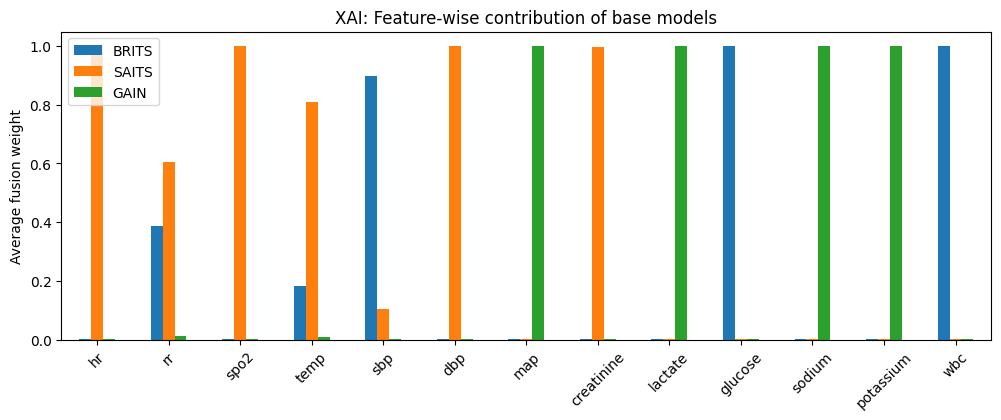

In [ ]:
xai_fusion_df.plot(kind="bar", figsize=(12,4))
plt.ylabel("Average fusion weight")
plt.title("XAI: Feature-wise contribution of base models")
plt.xticks(rotation=45)
plt.show()


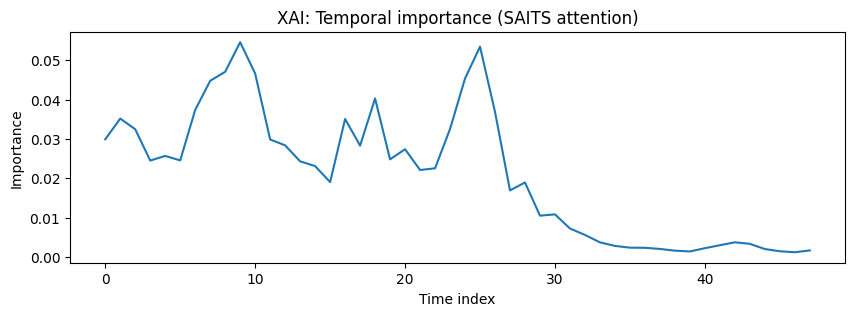

In [ ]:
# =========================
# XAI-2: Temporal importance via SAITS attention
# =========================

batch = next(iter(test_loader))
x = batch['x'].to(DEVICE)
m = batch['m'].to(DEVICE)

saits_model.eval()
with torch.no_grad():
    fused, impute, attn_maps = saits_model(x, m)

# Use attention from first SAITS block
attn = attn_maps[0].cpu().numpy()  # shape: B x heads x T x T or B x T x T

# Normalize shape
if attn.ndim == 3:
    attn = attn[:, None, :, :]

# Average across batch, heads, query time
time_importance = attn.mean(axis=(0,1,2))  # (T,)

plt.figure(figsize=(10,3))
plt.plot(time_importance)
plt.xlabel("Time index")
plt.ylabel("Importance")
plt.title("XAI: Temporal importance (SAITS attention)")
plt.show()


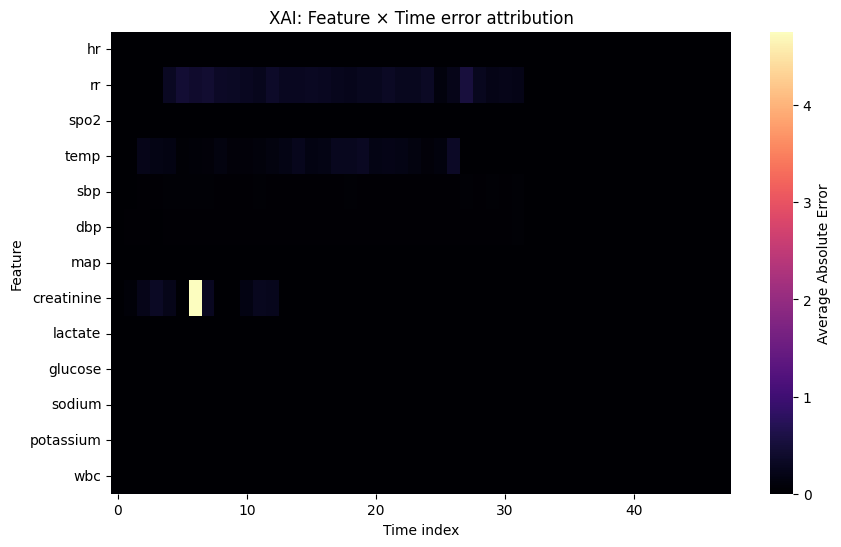

In [ ]:
# =========================
# XAI-3: Feature-time error attribution
# =========================

plt.figure(figsize=(10,6))
sns.heatmap(
    avg_error.T,
    cmap="magma",
    xticklabels=10,
    yticklabels=NUMERIC_FEATURES,
    cbar_kws={'label': 'Average Absolute Error'}
)
plt.xlabel("Time index")
plt.ylabel("Feature")
plt.title("XAI: Feature × Time error attribution")
plt.show()
